In [110]:

# Necessário para instalação das bibliotecas na etapa 4.1
# (Opcional) Verificação por seleção automática de ordem via pmdarima (AIC)

!pip install pmdarima

# Análise Preditiva e Evolução da Matriz Elétrica Brasileira

**Autor:** André Luis Chaves Madeira  
**Curso:** Tecnólogo em Ciência de Dados e Business Intelligence — UCP 2026

### **Estrutura do Projeto (Metodologia KDD)**

| Etapa KDD | Processos Realizados | Descrição Técnica |
|:----------|:---------------------|:------------------|
| **1. Seleção** | Ingestão de Dados | Configuração do ambiente e coleta da base histórica da IEA (2015-2025). |
| **2. Pré-processamento** | Limpeza e Filtragem | Tratamento de nulos, filtragem geográfica (Brasil) e normalização temporal. |
| **3. Transformação** | Análise Estatística | Decomposição STL (Tendência/Sazonalidade) e Testes de Estacionariedade (ADF). |
| **4. Mineração de Dados** | Modelagem Preditiva | Implementação e treinamento dos algoritmos estocásticos (SARIMA) e de crescimento (Prophet). |
| **5. Interpretação/Avaliação**| Validação e Projeção | Análise de métricas (MAE/RMSE/MAPE), cálculo de CAGR e projeções para 2026. |

## Revisões aplicadas

Esta versão do notebook incorpora as sugestões **metodologicas** do relatorio de
revisão que dependem do codigo.
| Item | Mudanca no codigo |
|-----|-------------------|
| 2.1 | Validacao **out-of-sample** (treino ate dez/2023, teste no restante) - ETAPA 5.1 |
| 2.2 | **CAGR** recalculado a partir de ano-base com geracao relevante (2018) e anos completos - ETAPA 2.1 |
| 2.3 | Tabela de **parametros SARIMA** `(p,d,q)(P,D,Q)s` + AIC/BIC (e verificacao `auto_arima`) - ETAPA 4.1 |
| 2.4 | **Analise de residuos**: ACF/PACF, Ljung-Box e QQ-plot - ETAPA 4.2 |
| 2.5 | **IC padronizado em 95%** no Prophet (`interval_width=0.95`) para coincidir com o SARIMA - ETAPA 4 |
| 4.5 | **sMAPE** e metricas truncadas a partir de 2018 - ETAPA 5 e 5.1 |
| 2.7 | **ADF após diferenciação** confirmando a ordem de integração (d=1; solar d=1,D=1) - ETAPA 3 |


## ETAPA 0 - EXIBIÇÃO DO DATASET INICIAL

In [111]:
# ==============================================================================
# EXIBIÇÃO DO DATASET INICIAL
# # Visão geral da base bruta antes do pré-processamento
# ==============================================================================

import pandas as pd

# URL da base de dados oficial do seu TCC
URL = "https://raw.githubusercontent.com/andrelcmadeira/TCC/main/base_completa_iea.csv"
df_raw = pd.read_csv(URL, sep=";")

print("1. Primeiras 5 linhas:")
display(df_raw.head())

print("\n2. Contagem de linhas e colunas:")
print(f"Linhas: {df_raw.shape[0]} | Colunas: {df_raw.shape[1]}")

print(f"\n3. Países disponíveis ({len(df_raw['COUNTRY'].unique())} países):")
print(df_raw['COUNTRY'].unique())

print(f"\n4. Produtos disponíveis ({len(df_raw['PRODUCT'].unique())} produtos):")
print(df_raw['PRODUCT'].unique())

print("\n5. Colunas com valores nulos/vazios:")
print(df_raw.isnull().sum())

print("\n6. Tipos de dado (informações técnicas):")
print(df_raw.info())

1. Primeiras 5 linhas:


,COUNTRY,CODE_TIME,TIME,YEAR,MONTH,MONTH_NAME,PRODUCT,VALUE,DISPLAY_ORDER,yearToDate,previousYearToDate,share
0,Argentina,JAN2015,January 2015,2015,1,January,Hydro,2519.945,1,2519.945,NaN,0.209872
1,Argentina,JAN2015,January 2015,2015,1,January,Wind,51.294,2,51.294,NaN,0.004272
2,Argentina,JAN2015,January 2015,2015,1,January,Solar,1.511,3,1.511,NaN,0.000126
3,Argentina,JAN2015,January 2015,2015,1,January,Geothermal,0.000,4,0.000,NaN,0.000000
4,Argentina,JAN2015,January 2015,2015,1,January,Other renewables,0.000,5,0.000,NaN,0.000000



2. Contagem de linhas e colunas:
Linhas: 183068 | Colunas: 12

3. Países disponíveis (43 países):
['Argentina' 'Australia' 'Austria' 'Belgium' 'Brazil' 'Bulgaria' 'Canada'
 'Chile' 'Greece' 'Hungary' 'IEA Total' 'Iceland' 'India' 'Ireland'
 'Italy' 'Japan' 'Korea' 'Latvia' 'Lithuania' 'Luxembourg' 'Malta'
 'Mexico' 'Netherlands' 'New Zealand' 'North Macedonia' 'Norway'
 'OECD Americas' 'OECD Asia Oceania' 'OECD Europe' 'OECD Total'
 "People's Republic of China" 'Poland' 'Portugal' 'Republic of Turkiye'
 'Romania' 'Serbia' 'Slovak Republic' 'Slovenia' 'Spain' 'Sweden'
 'Switzerland' 'United Kingdom' 'United States']

4. Produtos disponíveis (27 produtos):
['Hydro' 'Wind' 'Solar' 'Geothermal' 'Other renewables' 'Nuclear'
 'Total combustible fuels' 'Coal' 'Oil' 'Natural gas'
 'Combustible renewables' 'Other combustible non-renewables'
 'Net electricity production' 'Total imports' 'Total exports'
 'Electricity supplied' 'Used for pumped storage' 'Distribution losses'
 'Final consumption' 

# ETAPA 1

In [112]:
# ==============================================================================
# ETAPA 1: SELEÇÃO E CONFIGURAÇÃO
# ==============================================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# --- PARÂMETROS E PALETA DE CORES ---
CORES = {
    "Hydro": "#1f77b4", "Wind": "#17becf", "Solar": "#f5a623",
    "Combustible renewables": "#2ca02c", "Geothermal": "#8B4513",
    "Other renewables": "#98df8a", "Natural gas": "#8c564b",
    "Coal": "#555555", "Oil": "#d62728", "Nuclear": "#9467bd",
    "Other combustible non-renewables": "#c5b0d5",
}

FONTES_RENOVAVEIS     = ["Hydro","Wind","Solar","Combustible renewables","Geothermal","Other renewables"]
FONTES_NAO_RENOVAVEIS = ["Natural gas","Coal","Oil","Nuclear","Other combustible non-renewables"]
FONTES_PRINCIPAIS     = FONTES_RENOVAVEIS + FONTES_NAO_RENOVAVEIS

# Estilo visual para os gráficos
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
    "axes.titlesize": 13, "axes.labelsize": 11, "legend.frameon": True
})

# --- INGESTÃO E VISÃO GERAL ---
URL = "https://raw.githubusercontent.com/andrelcmadeira/TCC/main/base_completa_iea.csv"
df_raw = pd.read_csv(URL, sep=";")


# ETAPA 2

In [113]:
# ==============================================================================
# ETAPA 2: PRÉ-PROCESSAMENTO
# ==============================================================================

# Estruturação da Data para o índice temporal
df_raw["Date"] = pd.to_datetime(df_raw[["YEAR", "MONTH"]].assign(day=1))

# Filtro: Brasil, período 2015-2025
filtro = (
    (df_raw["COUNTRY"].str.strip() == "Brazil") &
    (df_raw["Date"] >= "2015-01-01") &
    (df_raw["Date"] <= "2025-12-31") &
    (df_raw["PRODUCT"].isin(FONTES_PRINCIPAIS))
)
data_filt = df_raw[filtro].copy()

# --- Criação de colunas auxiliares necessárias para a EDA ---
data_filt['Ano'] = data_filt['Date'].dt.year
data_filt['Categoria'] = data_filt['PRODUCT'].apply(lambda x: 'Renovável' if x in FONTES_RENOVAVEIS else 'Não Renovável')

# Criação das séries temporais para Solar e Wind
serie_solar = data_filt[data_filt['PRODUCT'] == 'Solar'].groupby('Date')['VALUE'].sum().sort_index()
serie_wind = data_filt[data_filt['PRODUCT'] == 'Wind'].groupby('Date')['VALUE'].sum().sort_index()

print(f"Base filtrada com sucesso. Período analisado: {serie_solar.index.min().year} a {serie_solar.index.max().year}")
print(f"Colunas auxiliares 'Ano' e 'Categoria' adicionadas para a análise exploratória.")

Base filtrada com sucesso. Período analisado: 2015 a 2025
Colunas auxiliares 'Ano' e 'Categoria' adicionadas para a análise exploratória.


Visão geral da base filtrada para o Brasil

In [114]:
print('--- VISÃO GERAL DA BASE FILTRADA (BRASIL 2015-2025) ---')

print('\n1. Primeiras 5 linhas do dataset filtrado:')
display(data_filt.head())

print('\nÚltimas 5 linhas do dataset filtrado:')
display(data_filt.tail())


print('\n2. Contagem de linhas e colunas (Base Filtrada):')
print(f'Linhas: {data_filt.shape[0]} | Colunas: {data_filt.shape[1]}')

print('\n3. Produtos remanescentes na análise:')
print(data_filt['PRODUCT'].unique())

print('\n4. Colunas com valores nulos/vazios na base filtrada:')
print(data_filt.isnull().sum())

print('\n5. Informações técnicas (Dtypes):')
print(data_filt.info())

--- VISÃO GERAL DA BASE FILTRADA (BRASIL 2015-2025) ---

1. Primeiras 5 linhas do dataset filtrado:


,COUNTRY,CODE_TIME,TIME,YEAR,MONTH,MONTH_NAME,PRODUCT,VALUE,DISPLAY_ORDER,yearToDate,previousYearToDate,share,Date,Ano,Categoria
16931,Brazil,JAN2015,January 2015,2015,1,January,Hydro,34343.374,1,34343.374,NaN,0.681045,2015-01-01,2015,Renovável
16932,Brazil,JAN2015,January 2015,2015,1,January,Wind,1543.120,2,1543.120,NaN,0.030601,2015-01-01,2015,Renovável
16933,Brazil,JAN2015,January 2015,2015,1,January,Solar,2.613,3,2.613,NaN,0.000052,2015-01-01,2015,Renovável
16934,Brazil,JAN2015,January 2015,2015,1,January,Geothermal,0.000,4,0.000,NaN,0.000000,2015-01-01,2015,Renovável
16935,Brazil,JAN2015,January 2015,2015,1,January,Other renewables,0.000,5,0.000,NaN,0.000000,2015-01-01,2015,Renovável



Últimas 5 linhas do dataset filtrado:


,COUNTRY,CODE_TIME,TIME,YEAR,MONTH,MONTH_NAME,PRODUCT,VALUE,DISPLAY_ORDER,yearToDate,previousYearToDate,share,Date,Ano,Categoria
19906,Brazil,DEC2025,December 2025,2025,12,December,Coal,1478.125388,8,17602.334067,15825.919872,0.023013,2025-12-01,2025,Não Renovável
19907,Brazil,DEC2025,December 2025,2025,12,December,Oil,590.426108,9,7225.578683,11636.651044,0.009192,2025-12-01,2025,Não Renovável
19908,Brazil,DEC2025,December 2025,2025,12,December,Natural gas,6555.497294,10,69405.460182,56951.951587,0.102062,2025-12-01,2025,Não Renovável
19909,Brazil,DEC2025,December 2025,2025,12,December,Combustible renewables,2630.527117,11,54408.817507,53957.935762,0.040954,2025-12-01,2025,Renovável
19910,Brazil,DEC2025,December 2025,2025,12,December,Other combustible non-renewables,89.181403,12,1070.176836,1070.176836,0.001388,2025-12-01,2025,Não Renovável



2. Contagem de linhas e colunas (Base Filtrada):
Linhas: 1356 | Colunas: 15

3. Produtos remanescentes na análise:
['Hydro' 'Wind' 'Solar' 'Geothermal' 'Other renewables' 'Nuclear' 'Coal'
 'Oil' 'Natural gas' 'Combustible renewables'
 'Other combustible non-renewables']

4. Colunas com valores nulos/vazios na base filtrada:
COUNTRY                 0
CODE_TIME               0
TIME                    0
YEAR                    0
MONTH                   0
MONTH_NAME              0
PRODUCT                 0
VALUE                   0
DISPLAY_ORDER           0
yearToDate              0
previousYearToDate    132
share                   0
Date                    0
Ano                     0
Categoria               0
dtype: int64

5. Informações técnicas (Dtypes):
<class 'pandas.core.frame.DataFrame'>
Index: 1356 entries, 16931 to 19910
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   COUNTRY    

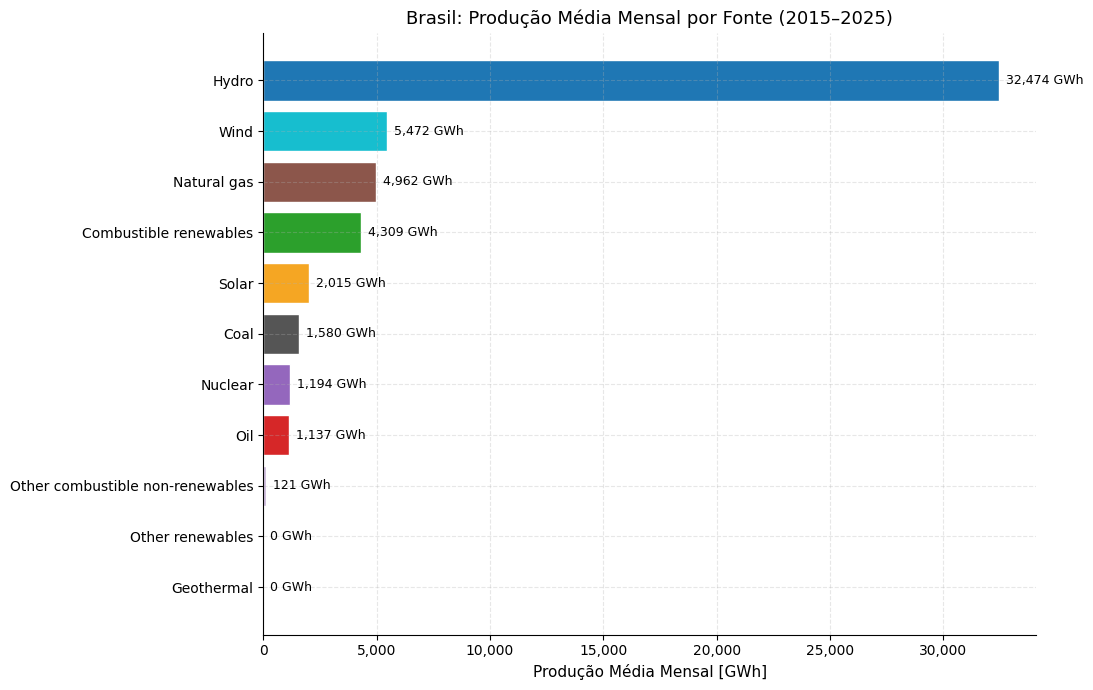

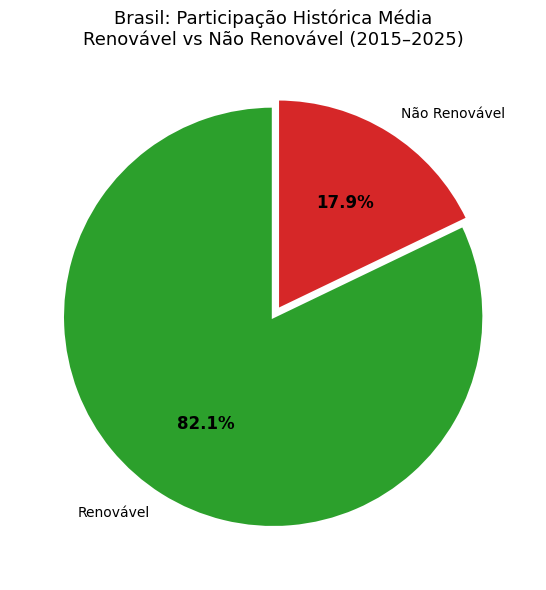

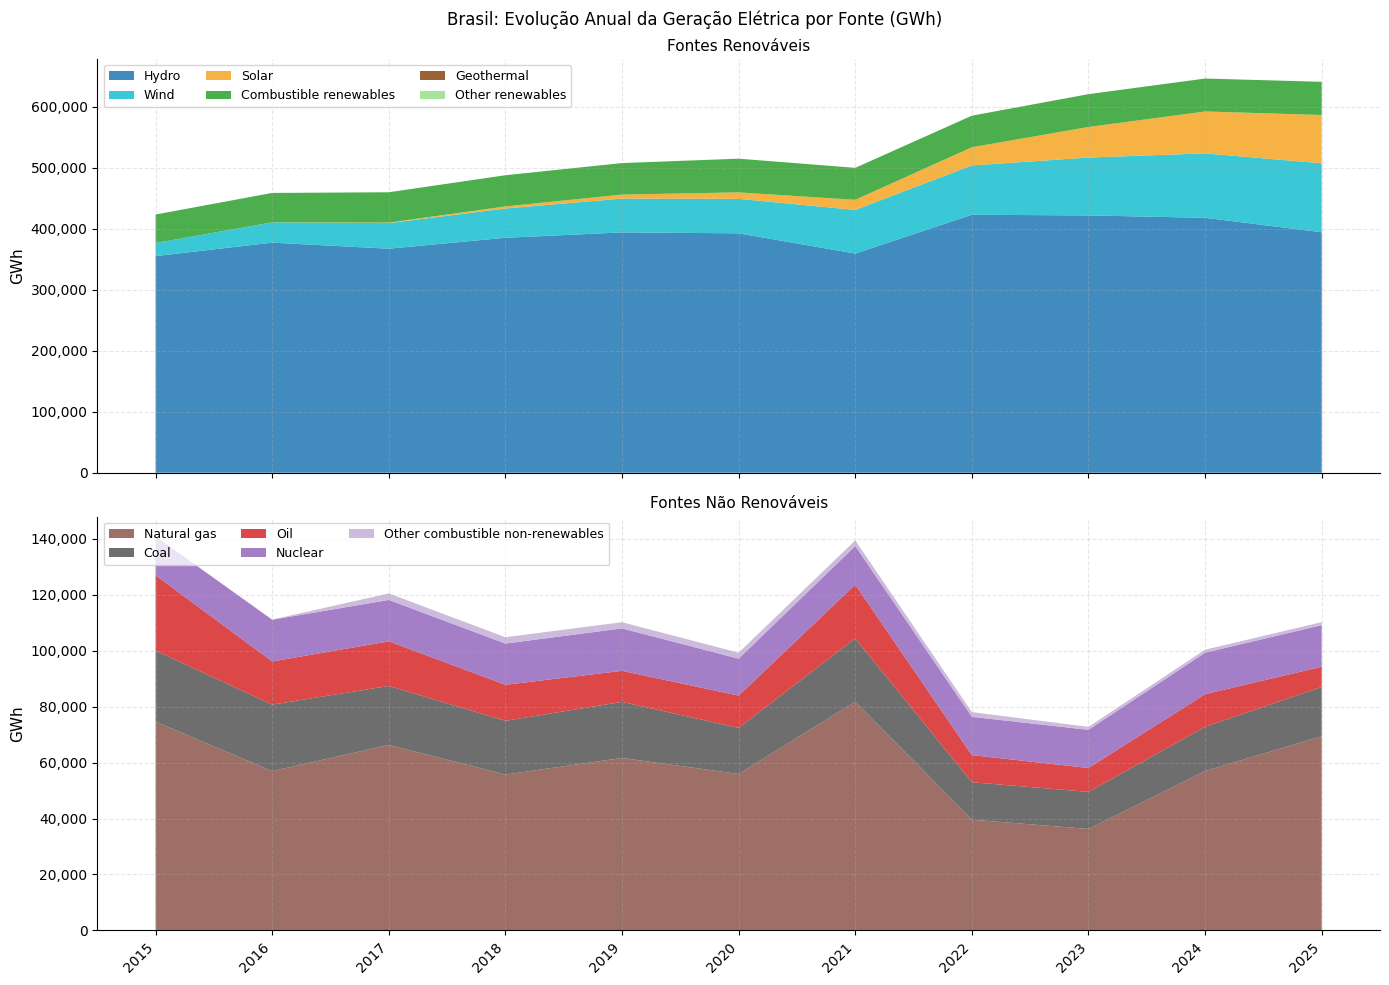

CAGR calculado do ano-base 2018 (geração relevante) ao último ano completo (2025).


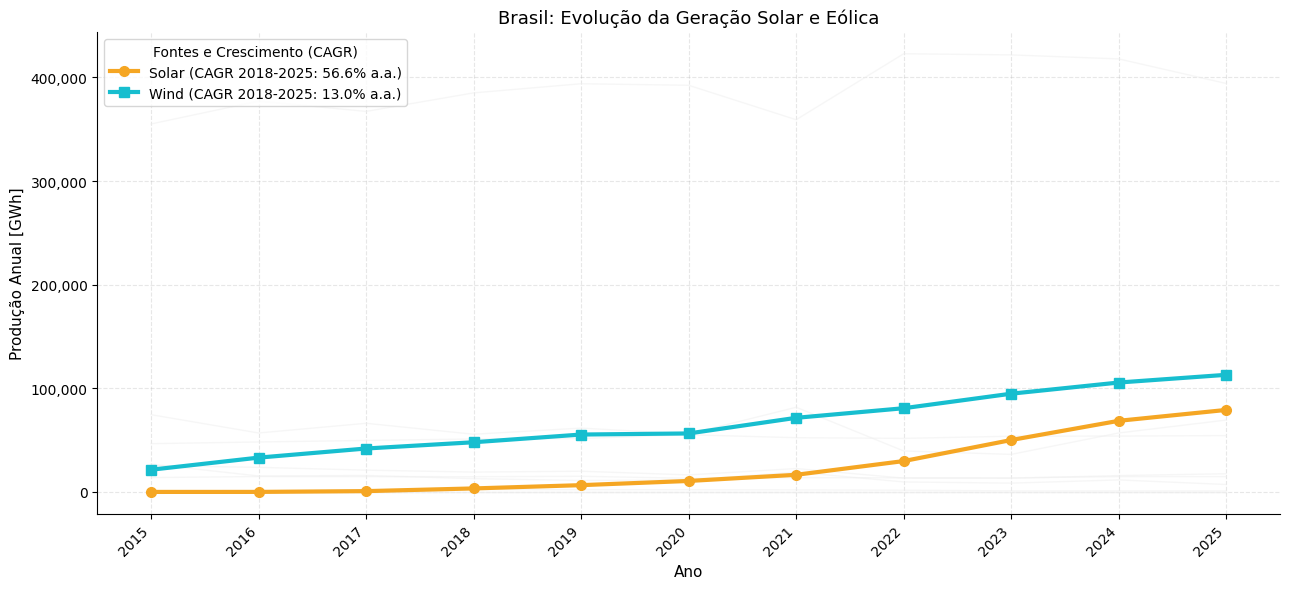

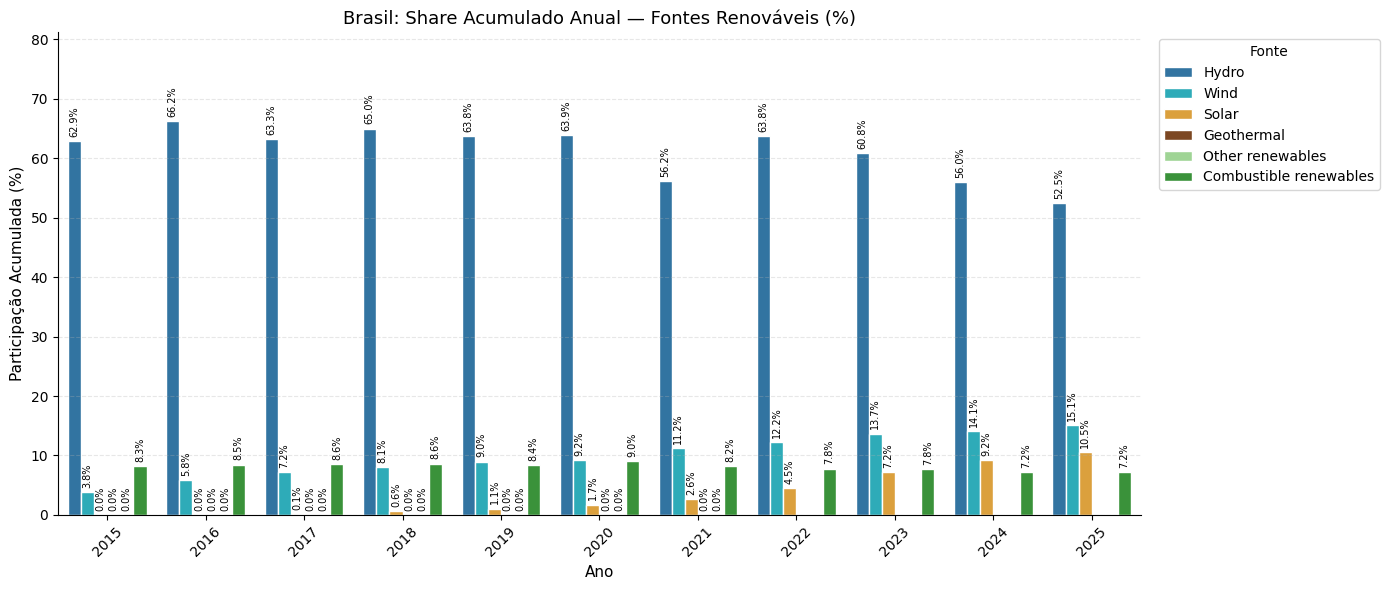

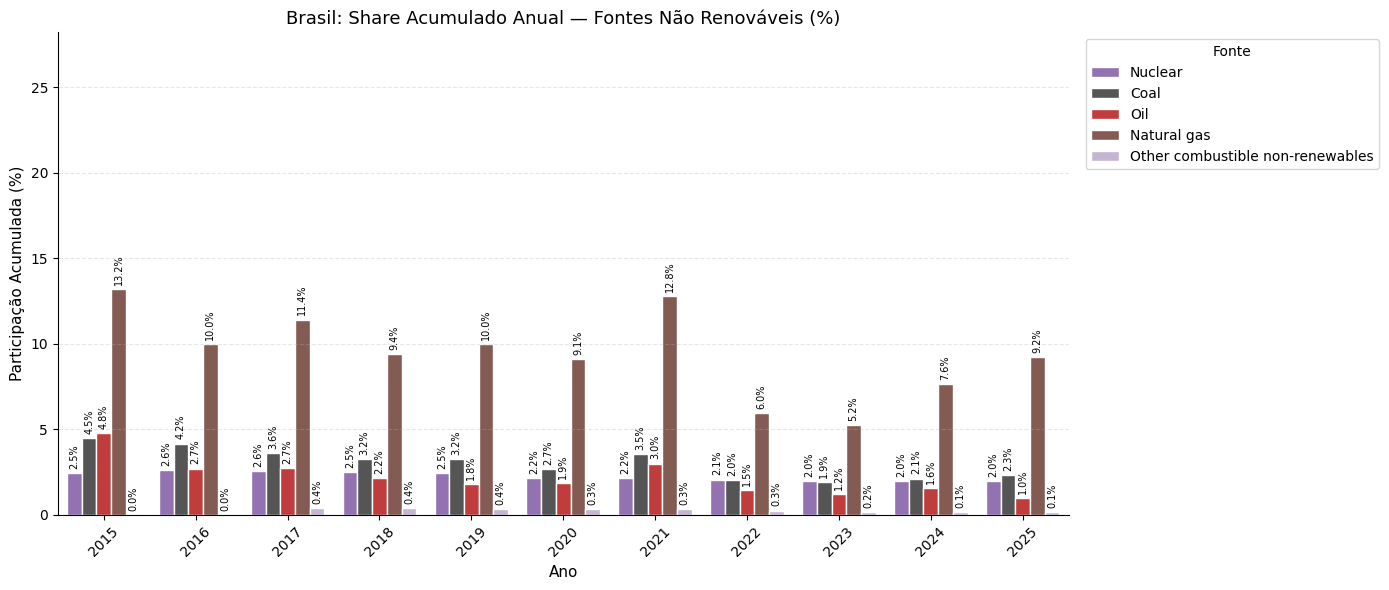

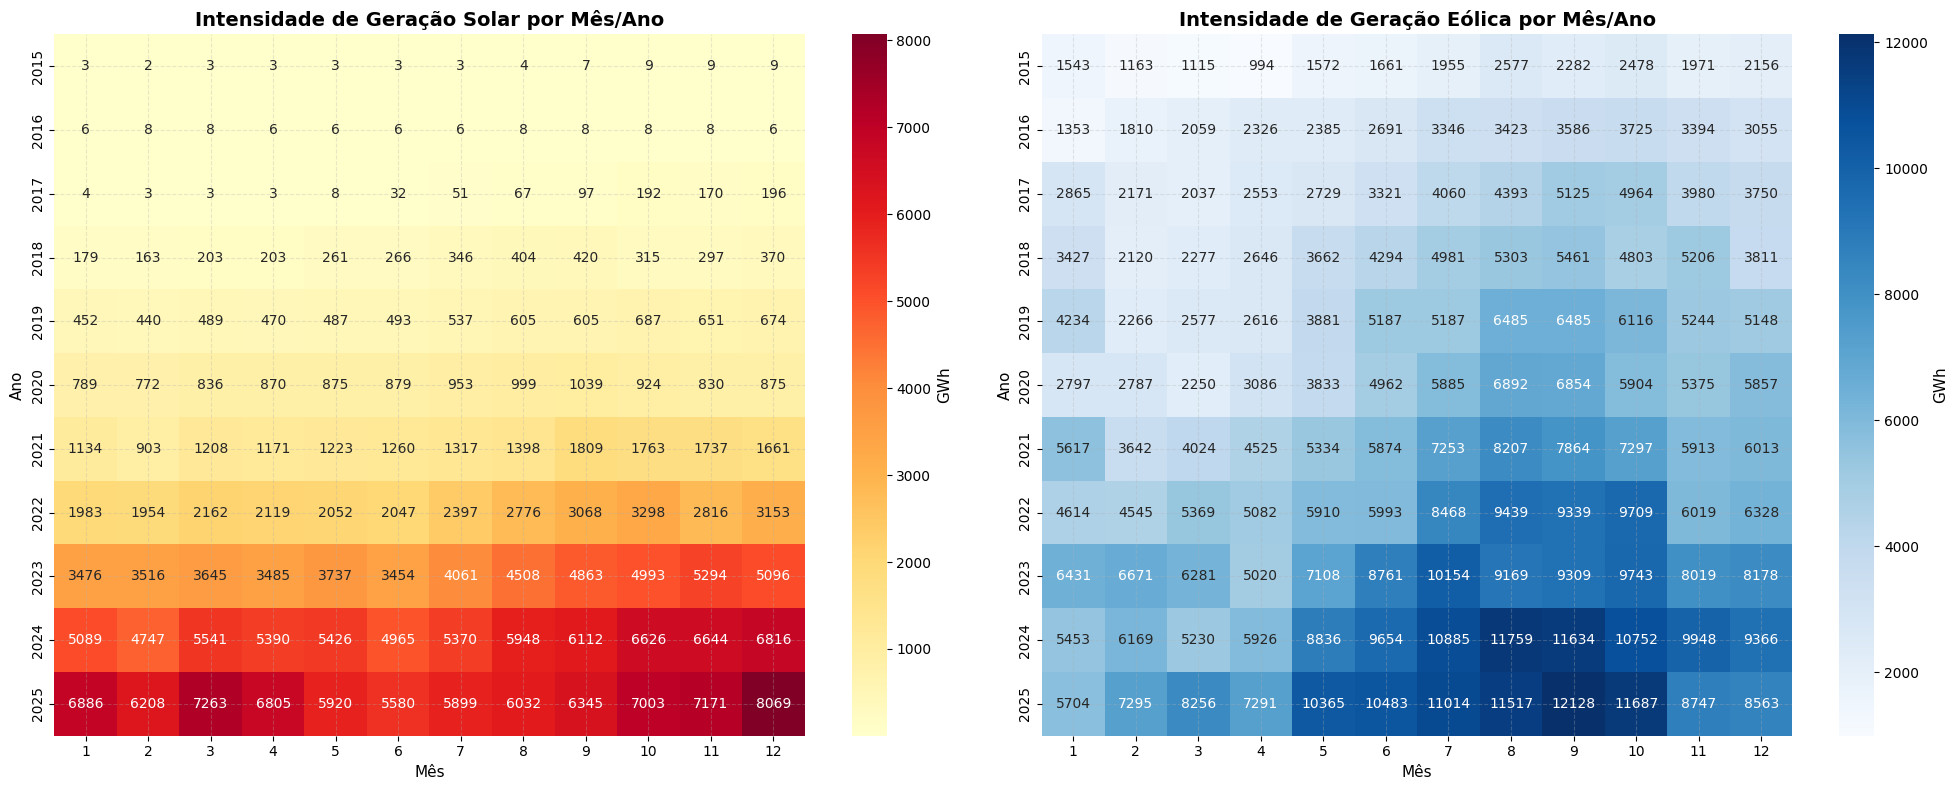

In [115]:
# ==============================================================================
# ETAPA 2.1: ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
# Visão analítica do comportamento histórico (2015 - 2025)
# ==============================================================================

import matplotlib.ticker as mticker
import seaborn as sns

# --- Preparação de Dados para os Gráficos ---
# data_anual: Agrupamento anual por produto
data_anual = data_filt.groupby(['Ano', 'PRODUCT'])['VALUE'].sum().unstack(fill_value=0)

# data_br: Base para cálculo de share (usando a base bruta filtrada para o Brasil)
filtro_br = (df_raw["COUNTRY"].str.strip() == "Brazil") & (df_raw["Date"] >= "2015-01-01")
data_br = df_raw[filtro_br].copy()

# Gráfico 1 — Produção média mensal por fonte
media_mensal = data_filt.groupby("PRODUCT")["VALUE"].mean().sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(media_mensal.index, media_mensal.values,
               color=[CORES.get(p,"#aaa") for p in media_mensal.index], edgecolor="white")

ax.bar_label(bars, labels=[f"{v:,.0f} GWh" for v in media_mensal.values], padding=5, fontsize=9)
ax.set_xlabel("Produção Média Mensal [GWh]")
ax.set_title("Brasil: Produção Média Mensal por Fonte (2015–2025)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
plt.tight_layout(); plt.show()

# Gráfico 2 — Pizza Renovável vs Não Renovável
rn_share = data_filt.groupby("Categoria")["share"].mean() * 100

fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    rn_share, labels=rn_share.index, autopct="%.1f%%",
    startangle=90, counterclock=False, colors=["#d62728","#2ca02c"],
    explode=(0.04,0), wedgeprops={"edgecolor":"white","linewidth":2})
[at.set_fontsize(12) or at.set_fontweight("bold") for at in autotexts]
ax.set_title("Brasil: Participação Histórica Média\nRenovável vs Não Renovável (2015–2025)")
plt.tight_layout(); plt.show()

# Gráfico 3 — Evolução anual (área empilhada)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Brasil: Evolução Anual da Geração Elétrica por Fonte (GWh)")

# Subplot 1: Renováveis
fontes_r = [f for f in FONTES_RENOVAVEIS if f in data_anual.columns]
ax1.stackplot(data_anual.index, [data_anual[f] for f in fontes_r],
              labels=fontes_r,
              colors=[CORES[f] for f in fontes_r], alpha=0.85)
ax1.set_ylabel("GWh"); ax1.set_title("Fontes Renováveis", fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
ax1.legend(loc="upper left", ncol=3, fontsize=9)

# Subplot 2: Não Renováveis
fontes_nr = [f for f in FONTES_NAO_RENOVAVEIS if f in data_anual.columns]
ax2.stackplot(data_anual.index, [data_anual[f] for f in fontes_nr],
              labels=fontes_nr,
              colors=[CORES[f] for f in fontes_nr], alpha=0.85)
ax2.set_ylabel("GWh"); ax2.set_title("Fontes Não Renováveis", fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
ax2.legend(loc="upper left", ncol=3, fontsize=9)

ax2.set_xticks(data_anual.index)
ax2.set_xticklabels(data_anual.index, rotation=45, ha="right")
plt.tight_layout(); plt.show()

# Gráfico 4 - Solar e Eólica em destaque com CAGR
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(13, 6))

# Linhas de fundo (outras fontes) em cinza claro
for col in data_anual.columns:
    if col not in ["Solar","Wind"]:
        ax.plot(data_anual.index, data_anual[col], color="#EEEEEE", linewidth=1, alpha=0.5)

# --- CAGR corrigido (revisão item 2.2) ---
# Os anos de 2015-2016 têm geração próxima de zero, o que distorce o CAGR
# (valores acima de 100% a.a.). Calcula-se o CAGR a partir de um ano-base com
# geração relevante (2018) e usando apenas anos COMPLETOS (12 meses), evitando
# a subestimação causada por um ano final parcial.
ANO_BASE_CAGR = 2018
meses_por_ano = data_filt.groupby('Ano')['Date'].nunique()
anos_completos = meses_por_ano[meses_por_ano >= 12].index
ANO_FINAL_CAGR = int(max(anos_completos)) if len(anos_completos) else int(data_anual.index.max())

# Destaque para Solar e Eólica com cálculo de CAGR a partir do ano-base
for fonte, marker in [("Solar","o"),("Wind","s")]:
    if fonte in data_anual.columns:
        s = data_anual[fonte].dropna()
        if (ANO_BASE_CAGR in s.index and ANO_FINAL_CAGR in s.index
                and s.loc[ANO_BASE_CAGR] > 0):
            n = ANO_FINAL_CAGR - ANO_BASE_CAGR
            cagr_val = (s.loc[ANO_FINAL_CAGR] / s.loc[ANO_BASE_CAGR])**(1/n) - 1
            label_cagr = f"{fonte} (CAGR {ANO_BASE_CAGR}-{ANO_FINAL_CAGR}: {cagr_val:.1%} a.a.)"
        else:
            label_cagr = fonte

        ax.plot(data_anual.index, data_anual[fonte], color=CORES[fonte],
                linewidth=3, marker=marker, markersize=7, label=label_cagr)

print(f"CAGR calculado do ano-base {ANO_BASE_CAGR} (geração relevante) ao último "
      f"ano completo ({ANO_FINAL_CAGR}).")

ax.set_title("Brasil: Evolução da Geração Solar e Eólica")
ax.set_xlabel("Ano")
ax.set_ylabel("Produção Anual [GWh]")

# Ajustes de eixos e legenda
ax.set_xticks(data_anual.index)
ax.set_xticklabels(data_anual.index, rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
ax.legend(title="Fontes e Crescimento (CAGR)", loc="upper left")

plt.tight_layout()
plt.show()

# Gráficos 5 e 6 — Share acumulado anual
df_dez  = data_br[data_br["MONTH_NAME"]=="December"].copy()
df_net  = (df_dez[df_dez["PRODUCT"]=="Net electricity production"]
           [["YEAR","yearToDate"]].rename(columns={"yearToDate":"total_anual_net"}))
df_sacc = pd.merge(df_dez, df_net, on="YEAR")
df_sacc["share_acumulado"] = df_sacc["yearToDate"] / df_sacc["total_anual_net"] * 100

for grupo, fontes, titulo_g in [
    ("Renováveis", FONTES_RENOVAVEIS, "Brasil: Share Acumulado Anual — Fontes Renováveis (%)"),
    ("Não Renováveis", FONTES_NAO_RENOVAVEIS, "Brasil: Share Acumulado Anual — Fontes Não Renováveis (%)"),
]:
    df_g = df_sacc[df_sacc["PRODUCT"].isin(fontes)]
    if df_g.empty: continue
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(data=df_g, x="YEAR", y="share_acumulado", hue="PRODUCT", palette=CORES, ax=ax, edgecolor="white")
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.1f%%", padding=3, fontsize=7, rotation=90)
    ax.set_ylim(0, df_g["share_acumulado"].max() + 15)
    ax.set_xlabel("Ano"); ax.set_ylabel("Participação Acumulada (%)")
    ax.set_title(titulo_g); ax.legend(title="Fonte", bbox_to_anchor=(1.01,1), loc="upper left")
    plt.xticks(rotation=45); plt.tight_layout();
    plt.show()

# Gráfico 7 - Heatmap Solar e eólica
# Preparação dos dados para o Heatmap
def preparar_heatmap(serie):
    df = serie.reset_index()
    df['Ano'] = df['Date'].dt.year
    df['Mes'] = df['Date'].dt.month
    return df.pivot(index="Ano", columns="Mes", values="VALUE")

# Criando os pivots
pivot_solar = preparar_heatmap(serie_solar)
pivot_wind = preparar_heatmap(serie_wind)

# Plotagem Lado a Lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Heatmap Solar
sns.heatmap(pivot_solar, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax1, cbar_kws={'label': 'GWh'})
ax1.set_title("Intensidade de Geração Solar por Mês/Ano", fontsize=14, fontweight='bold')
ax1.set_xlabel("Mês"); ax1.set_ylabel("Ano")

# Heatmap Eólica
sns.heatmap(pivot_wind, annot=True, fmt=".0f", cmap="Blues", ax=ax2, cbar_kws={'label': 'GWh'})
ax2.set_title("Intensidade de Geração Eólica por Mês/Ano", fontsize=14, fontweight='bold')
ax2.set_xlabel("Mês"); ax2.set_ylabel("Ano")

plt.tight_layout()
plt.show()

# ETAPA 3


ANÁLISE ESTATÍSTICA: ENERGIA SOLAR



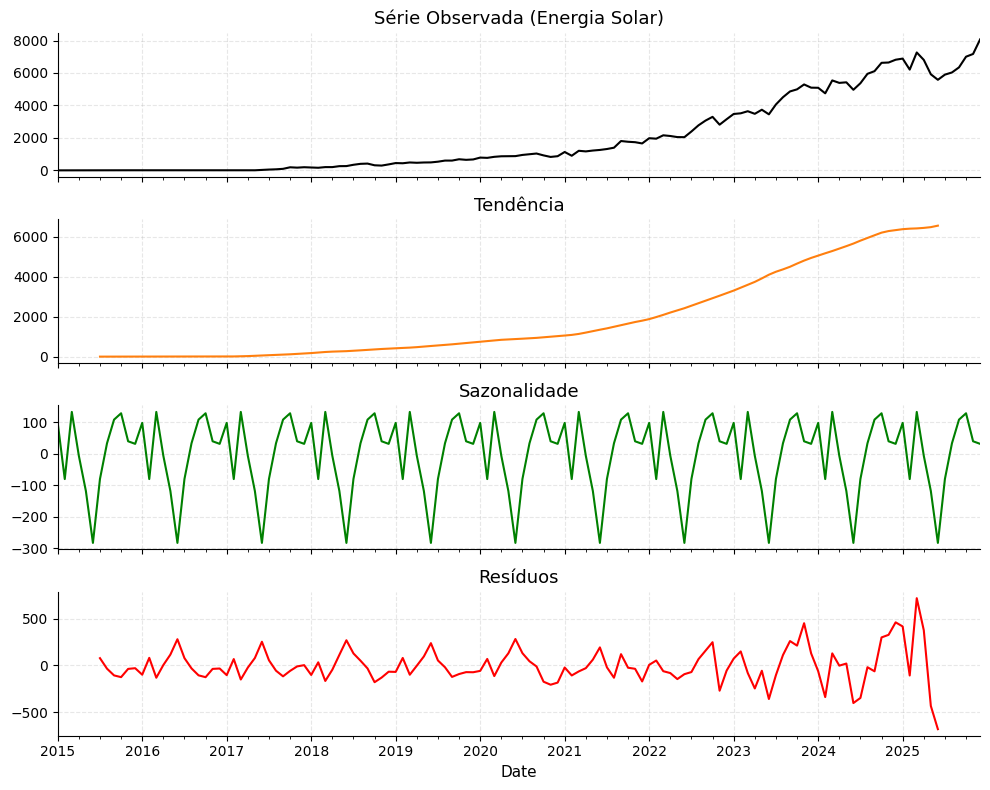

--- Teste Augmented Dickey-Fuller (ADF) - Energia Solar ---
Estatística do Teste: 0.7868
Valor-p: 0.9914
Conclusão: A série NÃO é estacionária (Requer diferenciação no SARIMA).

--- ADF após diferenciação - Energia Solar (confirma ordem de integração) ---
1ª diferença (d=1):            ADF = -1.3516 | p = 0.6053 -> NÃO estacionária
1ª dif. + sazonal (d=1, D=1): ADF = -12.9305 | p = 0.0000 -> estacionária
Conclusão: requer diferenciação regular e sazonal combinadas (d=1, D=1), conforme SARIMA(1,1,1)(1,1,1,12).


ANÁLISE ESTATÍSTICA: ENERGIA EÓLICA (WIND)



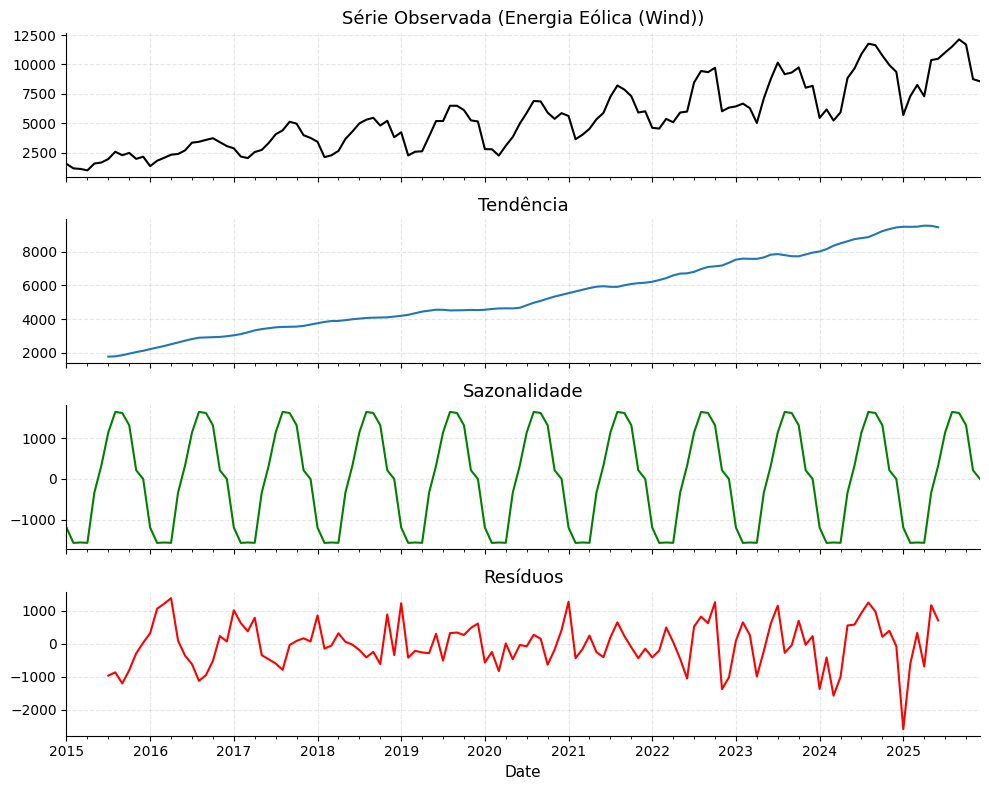

--- Teste Augmented Dickey-Fuller (ADF) - Energia Eólica (Wind) ---
Estatística do Teste: 0.3882
Valor-p: 0.9810
Conclusão: A série NÃO é estacionária (Requer diferenciação no SARIMA).

--- ADF após diferenciação - Energia Eólica (Wind) (confirma ordem de integração) ---
1ª diferença (d=1):            ADF = -9.1984 | p = 0.0000 -> estacionária
1ª dif. + sazonal (d=1, D=1): ADF = -3.9240 | p = 0.0019 -> estacionária
Conclusão: d=1 é suficiente para estacionarizar a série.



In [116]:
# ==============================================================================
# ETAPA 3: TRANSFORMAÇÃO E ANÁLISE ESTATÍSTICA
# Decomposição STL e Teste ADF para Energia Solar e Eólica
# ==============================================================================

def realizar_analise_estatistica(serie, nome_fonte, cor_tendencia):
    """
    Função para gerar a decomposição STL e aplicar o Teste ADF numa série temporal.
    """
    print(f"\n{'='*60}")
    print(f"ANÁLISE ESTATÍSTICA: {nome_fonte.upper()}")
    print(f"{'='*60}\n")

    # 1. Decomposição STL
    decomposicao = seasonal_decompose(serie, model='additive', period=12)

    # Plotagem dos subgráficos da decomposição
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    decomposicao.observed.plot(ax=axes[0], color='black', title=f'Série Observada ({nome_fonte})')
    decomposicao.trend.plot(ax=axes[1], color=cor_tendencia, title='Tendência')
    decomposicao.seasonal.plot(ax=axes[2], color='green', title='Sazonalidade')
    decomposicao.resid.plot(ax=axes[3], color='red', title='Resíduos')
    plt.tight_layout()
    plt.show()

    # 2. Teste ADF de Estacionariedade
    resultado_adf = adfuller(serie)
    print(f"--- Teste Augmented Dickey-Fuller (ADF) - {nome_fonte} ---")
    print(f"Estatística do Teste: {resultado_adf[0]:.4f}")
    print(f"Valor-p: {resultado_adf[1]:.4f}")

    if resultado_adf[1] <= 0.05:
        print("Conclusão: A série é estacionária (Rejeita-se a hipótese nula).\n")
    else:
        print("Conclusão: A série NÃO é estacionária (Requer diferenciação no SARIMA).\n")

    # 3. ADF após diferenciação - confirma a ordem de integração (revisão item 2.7)
    print(f"--- ADF após diferenciação - {nome_fonte} (confirma ordem de integração) ---")
    dif1 = serie.diff().dropna()
    r1 = adfuller(dif1)
    print(f"1ª diferença (d=1):            ADF = {r1[0]:.4f} | p = {r1[1]:.4f} -> "
          f"{'estacionária' if r1[1] <= 0.05 else 'NÃO estacionária'}")
    dif_sazonal = serie.diff().diff(12).dropna()
    r2 = adfuller(dif_sazonal)
    print(f"1ª dif. + sazonal (d=1, D=1): ADF = {r2[0]:.4f} | p = {r2[1]:.4f} -> "
          f"{'estacionária' if r2[1] <= 0.05 else 'NÃO estacionária'}")
    if r1[1] <= 0.05:
        print("Conclusão: d=1 é suficiente para estacionarizar a série.\n")
    else:
        print("Conclusão: requer diferenciação regular e sazonal combinadas "
              "(d=1, D=1), conforme SARIMA(1,1,1)(1,1,1,12).\n")

# --- EXECUÇÃO DAS ANÁLISES ---
# Análise para a Energia Solar
realizar_analise_estatistica(serie_solar, "Energia Solar", cor_tendencia="#ff7f0e")

# Análise para a Energia Eólica
realizar_analise_estatistica(serie_wind, "Energia Eólica (Wind)", cor_tendencia="#1f77b4")

# ETAPA 4

In [117]:
# ==============================================================================
# ETAPA 4: MINERAÇÃO DE DADOS (DATA MINING)
# Modelagem SARIMA e Prophet para Solar e Eólica
# ==============================================================================
# Revisão (item 2.5): o intervalo de confiança do Prophet foi padronizado em 95%
#   (interval_width=0.95) para coincidir com o IC de 95% do SARIMA, permitindo a
#   comparação direta das bandas de incerteza.
# Revisão (item 2.3): a função passa a retornar tambem o objeto ajustado do SARIMA
#   e o modelo Prophet, viabilizando o reporte de parametros e a analise de residuos.

PERIODOS_FUTURO = 12  # Projeção de 1 ano à frente

# Ordem do modelo SARIMA - documentada para reprodutibilidade (item 2.3)
SARIMA_ORDER = (1, 1, 1)
SARIMA_SEASONAL_ORDER = (1, 1, 1, 12)
NIVEL_CONFIANCA = 0.95  # 95% para SARIMA e Prophet (item 2.5)

def aplicar_modelos(serie):
    # --- MODELO SARIMA ---
    modelo_sarima = sm.tsa.statespace.SARIMAX(
        serie, order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL_ORDER,
        enforce_stationarity=False, enforce_invertibility=False)
    fit_sarima = modelo_sarima.fit(disp=False)

    # Extração de dados SARIMA
    prev_sarima_futuro = fit_sarima.get_forecast(steps=PERIODOS_FUTURO).predicted_mean
    prev_sarima_hist = fit_sarima.fittedvalues

    # --- MODELO PROPHET (IC de 95% - item 2.5) ---
    df_prophet = pd.DataFrame({'ds': serie.index, 'y': serie.values})
    modelo_prophet = Prophet(interval_width=NIVEL_CONFIANCA)
    modelo_prophet.fit(df_prophet)

    # Extração de dados Prophet
    df_futuro = modelo_prophet.make_future_dataframe(periods=PERIODOS_FUTURO, freq='MS')
    prev_prophet_completa = modelo_prophet.predict(df_futuro)

    prev_prophet_futuro = prev_prophet_completa.tail(PERIODOS_FUTURO)
    prev_prophet_hist = prev_prophet_completa['yhat'][:-PERIODOS_FUTURO].values

    return (prev_sarima_futuro, prev_sarima_hist, prev_prophet_futuro,
            prev_prophet_hist, fit_sarima, modelo_prophet)

print("Treinando modelos para Energia Solar...")
(s_futuro_solar, s_hist_solar, p_futuro_solar, p_hist_solar,
 fit_sarima_solar, prophet_solar) = aplicar_modelos(serie_solar)

print("Treinando modelos para Energia Eólica...")
(s_futuro_wind, s_hist_wind, p_futuro_wind, p_hist_wind,
 fit_sarima_wind, prophet_wind) = aplicar_modelos(serie_wind)

print("Treinamento e predições concluídos com sucesso!")


Treinando modelos para Energia Solar...


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Treinando modelos para Energia Eólica...


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Treinamento e predições concluídos com sucesso!


## ETAPA 4.1 - Parametros do SARIMA e Criterios de Informacao (revisao item 2.3)

Reporte de `(p,d,q)(P,D,Q)s`, AIC e BIC para garantir a reprodutibilidade cientifica do modelo.

In [118]:
# ==============================================================================
# ETAPA 4.1: PARÂMETROS DO SARIMA E CRITÉRIOS DE INFORMAÇÃO  (revisão item 2.3)
# Reporte de (p,d,q)(P,D,Q)s, AIC e BIC para reprodutibilidade científica.
# ==============================================================================

def resumo_parametros_sarima(nome, fit):
    return {
        'Série': nome,
        'Ordem (p,d,q)': str(SARIMA_ORDER),
        'Sazonal (P,D,Q,s)': str(SARIMA_SEASONAL_ORDER),
        'AIC': round(fit.aic, 2),
        'BIC': round(fit.bic, 2),
        'Log-Veross.': round(fit.llf, 2),
    }

tabela_parametros = pd.DataFrame([
    resumo_parametros_sarima('Solar', fit_sarima_solar),
    resumo_parametros_sarima('Eólica', fit_sarima_wind),
])

print("=" * 80)
print("  TABELA DE PARÂMETROS DO MODELO SARIMA (item 2.3 do relatório de revisão)")
print("=" * 80)
print(tabela_parametros.to_string(index=False))
print("=" * 80)
print("\nCritério de seleção: a ordem (1,1,1)(1,1,1)12 foi adotada com base na")
print("estrutura de autocorrelação (ACF/PACF) e na comparação por AIC/BIC.")
display(tabela_parametros)

# (Opcional) Verificação por seleção automática de ordem via pmdarima (AIC)
try:
    import pmdarima as pm
    print("\n--- Verificação por auto_arima (pmdarima), seleção por AIC ---")
    for nome, serie in [('Solar', serie_solar), ('Eólica', serie_wind)]:
        auto = pm.auto_arima(serie, seasonal=True, m=12, stepwise=True,
                             suppress_warnings=True, error_action='ignore',
                             information_criterion='aic')
        print(f"{nome}: melhor ordem por AIC -> "
              f"{auto.order}{auto.seasonal_order} | AIC = {auto.aic():.2f}")
except Exception:
    print("\n[Info] pmdarima não disponível neste ambiente; os parâmetros foram")
    print("reportados a partir do ajuste manual (AIC/BIC na tabela acima).")
    print("Para habilitar a verificação automática no Colab: !pip install pmdarima")


  TABELA DE PARÂMETROS DO MODELO SARIMA (item 2.3 do relatório de revisão)
 Série Ordem (p,d,q) Sazonal (P,D,Q,s)     AIC     BIC  Log-Veross.
 Solar     (1, 1, 1)     (1, 1, 1, 12) 1442.92 1456.19      -716.46
Eólica     (1, 1, 1)     (1, 1, 1, 12) 1698.31 1711.58      -844.16

Critério de seleção: a ordem (1,1,1)(1,1,1)12 foi adotada com base na
estrutura de autocorrelação (ACF/PACF) e na comparação por AIC/BIC.


,Série,"Ordem (p,d,q)","Sazonal (P,D,Q,s)",AIC,BIC,Log-Veross.
0,Solar,"(1, 1, 1)","(1, 1, 1, 12)",1442.92,1456.19,-716.46
1,Eólica,"(1, 1, 1)","(1, 1, 1, 12)",1698.31,1711.58,-844.16



--- Verificação por auto_arima (pmdarima), seleção por AIC ---
Solar: melhor ordem por AIC -> (0, 1, 1)(0, 1, 0, 12) | AIC = 1614.77
Eólica: melhor ordem por AIC -> (1, 1, 1)(1, 0, 1, 12) | AIC = 2118.38


## ETAPA 4.2 - Analise de Residuos dos Modelos (revisao item 2.4)

Diagnostico de validacao em series temporais: ACF/PACF dos residuos, teste de Ljung-Box (autocorrelacao) e QQ-plot (normalidade).


DIAGNÓSTICO DE RESÍDUOS: Energia Solar


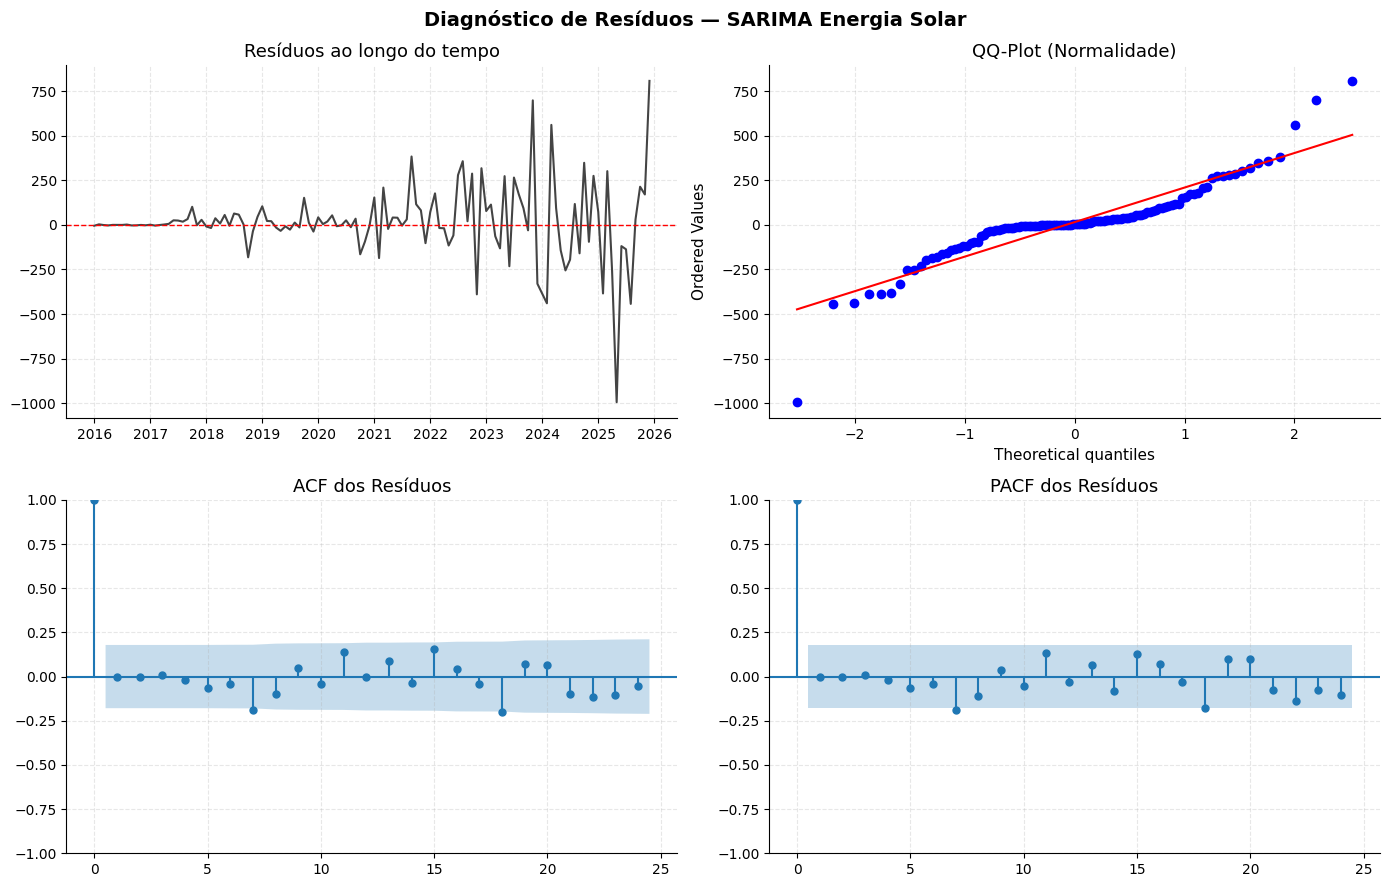

Teste de Ljung-Box (H0: ausência de autocorrelação nos resíduos):
      lb_stat  lb_pvalue
12   9.800194   0.633485
24  27.596850   0.277410
-> Valores-p > 0,05: sem evidência de autocorrelação residual (modelo adequado).

Teste de Shapiro-Wilk (normalidade): estatística = 0.8586 | valor-p = 0.0000
-> Resíduos desviam da normalidade (p < 0,05).


DIAGNÓSTICO DE RESÍDUOS: Energia Eólica


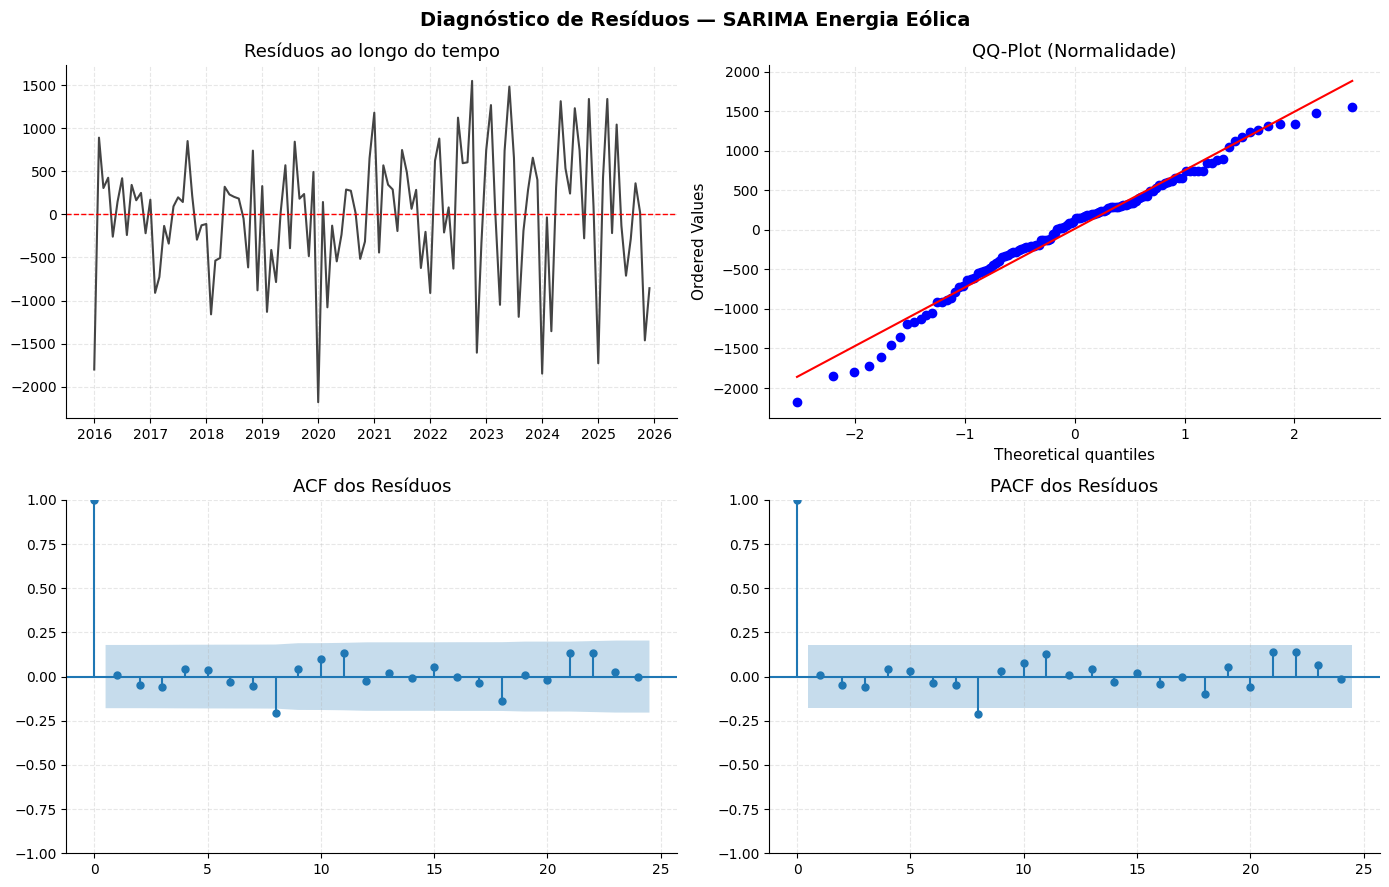

Teste de Ljung-Box (H0: ausência de autocorrelação nos resíduos):
      lb_stat  lb_pvalue
12  11.440765   0.491570
24  20.528353   0.666368
-> Valores-p > 0,05: sem evidência de autocorrelação residual (modelo adequado).

Teste de Shapiro-Wilk (normalidade): estatística = 0.9785 | valor-p = 0.0515
-> Resíduos compatíveis com a normalidade.



In [119]:
# ==============================================================================
# ETAPA 4.2: ANÁLISE DE RESÍDUOS DO SARIMA  (revisão item 2.4)
# ACF/PACF dos resíduos, teste de Ljung-Box e QQ-plot de normalidade.
# ==============================================================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import scipy.stats as stats

def diagnosticar_residuos(nome, fit):
    print(f"\n{'='*60}\nDIAGNÓSTICO DE RESÍDUOS: {nome}\n{'='*60}")
    residuos = fit.resid.dropna()
    # Descarta o aquecimento inicial do filtro (primeiros valores instáveis)
    inicio = SARIMA_SEASONAL_ORDER[3] if len(residuos) > SARIMA_SEASONAL_ORDER[3] else 0
    residuos = residuos.iloc[inicio:]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f"Diagnóstico de Resíduos — SARIMA {nome}", fontsize=14, fontweight='bold')

    # 1. Resíduos no tempo
    axes[0, 0].plot(residuos.index, residuos.values, color='#444')
    axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[0, 0].set_title("Resíduos ao longo do tempo")

    # 2. QQ-plot (normalidade)
    stats.probplot(residuos, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title("QQ-Plot (Normalidade)")

    # 3. ACF e 4. PACF dos resíduos
    n_lags = min(24, len(residuos) // 2 - 1)
    plot_acf(residuos, ax=axes[1, 0], lags=n_lags)
    axes[1, 0].set_title("ACF dos Resíduos")
    plot_pacf(residuos, ax=axes[1, 1], lags=n_lags, method='ywm')
    axes[1, 1].set_title("PACF dos Resíduos")

    plt.tight_layout()
    plt.show()

    # Teste de Ljung-Box (H0: resíduos sem autocorrelação)
    lags_lb = [l for l in (12, 24) if l < len(residuos)]
    lb = acorr_ljungbox(residuos, lags=lags_lb, return_df=True)
    print("Teste de Ljung-Box (H0: ausência de autocorrelação nos resíduos):")
    print(lb.to_string())
    p_min = lb['lb_pvalue'].min()
    if p_min > 0.05:
        print("-> Valores-p > 0,05: sem evidência de autocorrelação residual "
              "(modelo adequado).\n")
    else:
        print(f"-> Há autocorrelação residual em algum lag "
              f"(valor-p mínimo = {p_min:.4f}); considerar reespecificação.\n")

    # Teste de normalidade dos resíduos (Shapiro-Wilk)
    sw_stat, sw_p = stats.shapiro(residuos)
    print(f"Teste de Shapiro-Wilk (normalidade): estatística = {sw_stat:.4f} | "
          f"valor-p = {sw_p:.4f}")
    print("-> Resíduos compatíveis com a normalidade.\n" if sw_p > 0.05
          else "-> Resíduos desviam da normalidade (p < 0,05).\n")

diagnosticar_residuos("Energia Solar", fit_sarima_solar)
diagnosticar_residuos("Energia Eólica", fit_sarima_wind)


# ETAPA 5

NOTA (item 2.1): métricas IN-SAMPLE abaixo; a validação OUT-OF-SAMPLE (dados não vistos) está na ETAPA 5.1.

--- AVALIAÇÃO DE DESEMPENHO (IN-SAMPLE): ENERGIA SOLAR ---
SARIMA  -> MAE: 111.26 | RMSE: 198.31 | MAPE: 14.24% | sMAPE: 15.83%
PROPHET -> MAE: 196.25 | RMSE: 277.37 | MAPE: 751.11% | sMAPE: 53.56%
----------------------------------------------------------------------
--- AVALIAÇÃO DE DESEMPENHO (IN-SAMPLE): ENERGIA EÓLICA (WIND) ---
SARIMA  -> MAE: 558.27 | RMSE: 722.26 | MAPE: 13.92% | sMAPE: 13.83%
PROPHET -> MAE: 579.06 | RMSE: 715.69 | MAPE: 14.88% | sMAPE: 15.94%
----------------------------------------------------------------------


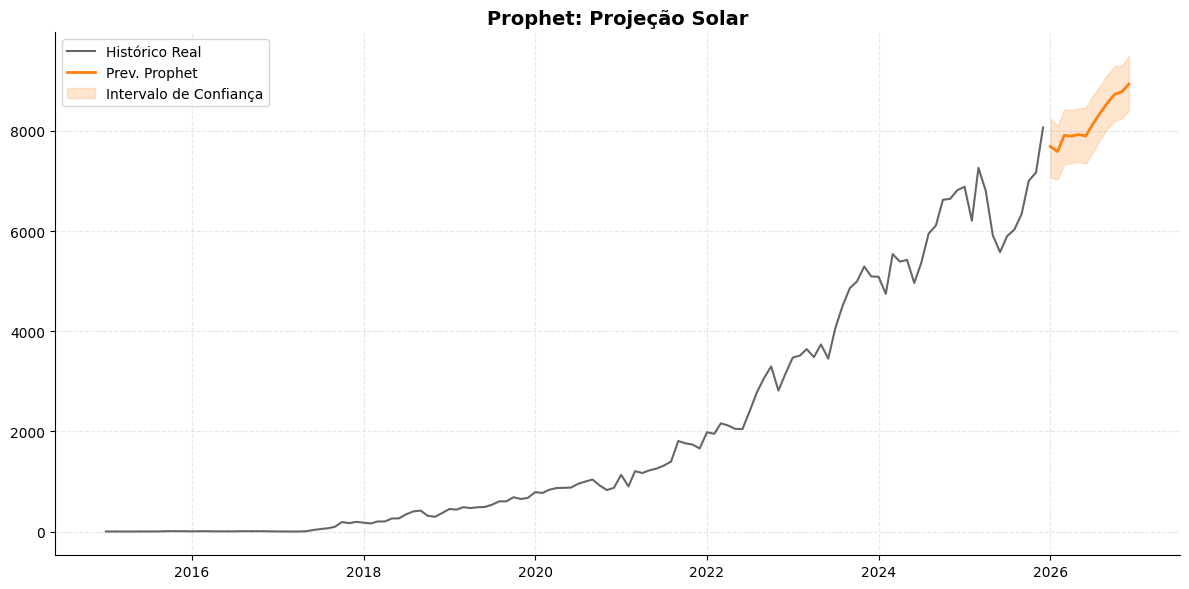

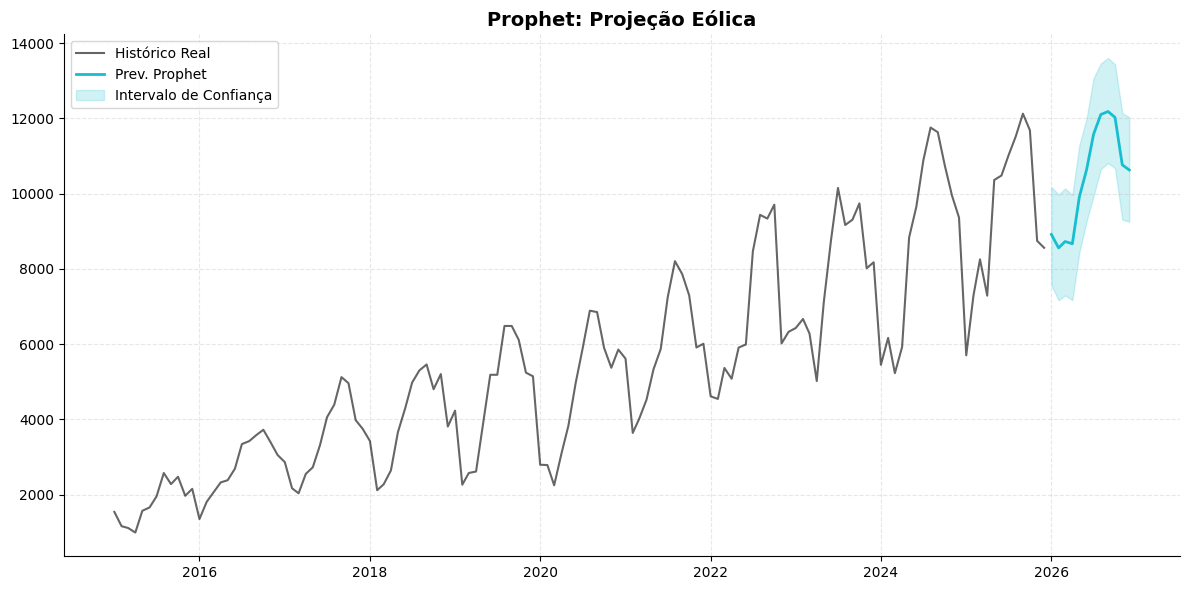


              TABELA DE PREVISÕES PARA 2026 (GWh)
    Mês  Solar - SARIMA  Solar - Prophet  Wind - SARIMA  Wind - Prophet
2026-01          7980.9           7690.0         6767.0          8918.5
2026-02          7373.2           7589.4         7975.1          8559.8
2026-03          8353.7           7911.4         8317.2          8729.6
2026-04          7951.5           7897.0         7911.1          8670.6
2026-05          7236.6           7927.0        10557.3          9915.0
2026-06          6886.2           7898.7        11092.8         10637.8
2026-07          7225.4           8138.0        12065.3         11579.9
2026-08          7430.6           8355.5        12531.0         12105.4
2026-09          7725.3           8559.4        12802.1         12184.9
2026-10          8341.0           8727.7        12398.3         12029.0
2026-11          8487.7           8781.8        10236.3         10767.8
2026-12          9244.8           8935.9        10038.1         10631.4



In [120]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Funções auxiliares de erro percentual
def calcular_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def calcular_smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    return np.mean(2 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask]) * 100

def imprimir_metricas(nome, serie, s_hist, p_hist):
    print(f"--- AVALIAÇÃO DE DESEMPENHO (IN-SAMPLE): {nome} ---")
    print(f"SARIMA  -> MAE: {mean_absolute_error(serie, s_hist):.2f} | "
          f"RMSE: {np.sqrt(mean_squared_error(serie, s_hist)):.2f} | "
          f"MAPE: {calcular_mape(serie, s_hist):.2f}% | "
          f"sMAPE: {calcular_smape(serie, s_hist):.2f}%")
    print(f"PROPHET -> MAE: {mean_absolute_error(serie, p_hist):.2f} | "
          f"RMSE: {np.sqrt(mean_squared_error(serie, p_hist)):.2f} | "
          f"MAPE: {calcular_mape(serie, p_hist):.2f}% | "
          f"sMAPE: {calcular_smape(serie, p_hist):.2f}%")
    print("-" * 70)

print("NOTA (item 2.1): métricas IN-SAMPLE abaixo; a validação OUT-OF-SAMPLE (dados não vistos) está na ETAPA 5.1.\n")

# Cálculo de Métricas (in-sample)
imprimir_metricas("ENERGIA SOLAR", serie_solar, s_hist_solar, p_hist_solar)
imprimir_metricas("ENERGIA EÓLICA (WIND)", serie_wind, s_hist_wind, p_hist_wind)

# 2. Gráficos Prophet Separados (para exportação individual)

# --- Solar - Prophet ---
plt.figure(figsize=(12, 6))
plt.plot(serie_solar.index, serie_solar.values, label='Histórico Real', color='black', alpha=0.6)
plt.plot(p_futuro_solar['ds'], p_futuro_solar['yhat'], label='Prev. Prophet', color='#ff7f0e', linewidth=2)
plt.fill_between(p_futuro_solar['ds'], p_futuro_solar['yhat_lower'], p_futuro_solar['yhat_upper'], color='#ff7f0e', alpha=0.2, label='Intervalo de Confiança')
plt.title("Prophet: Projeção Solar", fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# --- Eólica - Prophet ---
plt.figure(figsize=(12, 6))
plt.plot(serie_wind.index, serie_wind.values, label='Histórico Real', color='black', alpha=0.6)
plt.plot(p_futuro_wind['ds'], p_futuro_wind['yhat'], label='Prev. Prophet', color='#17becf', linewidth=2)
plt.fill_between(p_futuro_wind['ds'], p_futuro_wind['yhat_lower'], p_futuro_wind['yhat_upper'], color='#17becf', alpha=0.2, label='Intervalo de Confiança')
plt.title("Prophet: Projeção Eólica", fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# 3. Tabela de Previsões para 2026
meses_2026 = s_futuro_solar.index.strftime('%Y-%m')
df_previsoes_2026 = pd.DataFrame({
    'Mês': meses_2026,
    'Solar - SARIMA': s_futuro_solar.values.round(1),
    'Solar - Prophet': p_futuro_solar['yhat'].values.round(1),
    'Wind - SARIMA': s_futuro_wind.values.round(1),
    'Wind - Prophet': p_futuro_wind['yhat'].values.round(1)
})

print("\n" + "="*75)
print("              TABELA DE PREVISÕES PARA 2026 (GWh)")
print("="*75)
print(df_previsoes_2026.to_string(index=False))
print("="*75 + "\n")

## ETAPA 5.1 - Validação Out-of-Sample e Métricas Robustas (revisão itens 2.1 e 4.5)

Divisão treino/teste (treino ate dez/2023, teste no período restante). As métricas são calculadas sobre dados **não vistos no treino**, refletindo a real capacidade preditiva dos modelos. Inclui sMAPE e avaliação truncada a partir de 2018.

In [121]:
# ==============================================================================
# ETAPA 5.1: VALIDAÇÃO OUT-OF-SAMPLE  (revisão itens 2.1 e 4.5)
# Divisão treino/teste: treino até dez/2023, teste no período restante (2024+).
# As métricas refletem a capacidade preditiva real (dados não vistos no treino).
# ==============================================================================

DATA_CORTE = '2023-12-01'  # fim do período de treino

def avaliar_out_of_sample(nome, serie):
    treino = serie[serie.index <= DATA_CORTE]
    teste = serie[serie.index > DATA_CORTE]
    h = len(teste)
    if h == 0:
        print(f"[{nome}] Sem período de teste disponível após {DATA_CORTE}.")
        return []

    # SARIMA treinado apenas no conjunto de treino
    fit_s = sm.tsa.statespace.SARIMAX(
        treino, order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL_ORDER,
        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    pred_s = fit_s.get_forecast(steps=h).predicted_mean.values

    # Prophet treinado apenas no conjunto de treino
    dfp = pd.DataFrame({'ds': treino.index, 'y': treino.values})
    mp = Prophet(interval_width=NIVEL_CONFIANCA)
    mp.fit(dfp)
    fut = mp.make_future_dataframe(periods=h, freq='MS')
    pred_p = mp.predict(fut).tail(h)['yhat'].values

    y = teste.values
    linhas = []
    for modelo, pred in [('SARIMA', pred_s), ('Prophet', pred_p)]:
        linhas.append({
            'Série': nome, 'Modelo': modelo,
            'MAE': round(mean_absolute_error(y, pred), 2),
            'RMSE': round(np.sqrt(mean_squared_error(y, pred)), 2),
            'MAPE (%)': round(calcular_mape(y, pred), 2),
            'sMAPE (%)': round(calcular_smape(y, pred), 2),
        })
    return linhas

print("=" * 90)
print(f"  VALIDAÇÃO OUT-OF-SAMPLE  (treino até {DATA_CORTE[:7]}, teste no restante)")
print("=" * 90)
resultados_oos = []
for nome, serie in [('Solar', serie_solar), ('Eólica', serie_wind)]:
    resultados_oos.extend(avaliar_out_of_sample(nome, serie))

tabela_oos = pd.DataFrame(resultados_oos)
print(tabela_oos.to_string(index=False))
print("=" * 90)
display(tabela_oos)

# --- Métricas IN-SAMPLE truncadas a partir de 2018 (item 4.5) ---
# Remove 2015-2016 (geração próxima de zero), que infla o MAPE; o sMAPE complementa.
ANO_TRUNCAR = 2018

def metricas_truncadas(nome, serie, s_hist, p_hist):
    idx = serie.index.year >= ANO_TRUNCAR
    y = serie.values[idx]
    sh = np.array(s_hist)[idx]
    ph = np.array(p_hist)[idx]
    return [
        {'Série': nome, 'Modelo': 'SARIMA',
         'MAPE (%)': round(calcular_mape(y, sh), 2),
         'sMAPE (%)': round(calcular_smape(y, sh), 2)},
        {'Série': nome, 'Modelo': 'Prophet',
         'MAPE (%)': round(calcular_mape(y, ph), 2),
         'sMAPE (%)': round(calcular_smape(y, ph), 2)},
    ]

print(f"\nMétricas IN-SAMPLE truncadas a partir de {ANO_TRUNCAR} "
      f"(item 4.5 — mitiga o MAPE inflado por valores ~0):")
trunc = []
trunc += metricas_truncadas('Solar', serie_solar, s_hist_solar, p_hist_solar)
trunc += metricas_truncadas('Eólica', serie_wind, s_hist_wind, p_hist_wind)
tabela_trunc = pd.DataFrame(trunc)
print(tabela_trunc.to_string(index=False))
display(tabela_trunc)


  VALIDAÇÃO OUT-OF-SAMPLE  (treino até 2023-12, teste no restante)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


 Série  Modelo     MAE    RMSE  MAPE (%)  sMAPE (%)
 Solar  SARIMA  972.72 1219.63     15.83      14.13
 Solar Prophet  551.65  764.87      9.14       8.46
Eólica  SARIMA  858.71 1065.58     11.31      10.51
Eólica Prophet 1107.92 1243.10     13.92      13.13


,Série,Modelo,MAE,RMSE,MAPE (%),sMAPE (%)
0,Solar,SARIMA,972.72,1219.63,15.83,14.13
1,Solar,Prophet,551.65,764.87,9.14,8.46
2,Eólica,SARIMA,858.71,1065.58,11.31,10.51
3,Eólica,Prophet,1107.92,1243.10,13.92,13.13



Métricas IN-SAMPLE truncadas a partir de 2018 (item 4.5 — mitiga o MAPE inflado por valores ~0):
 Série  Modelo  MAPE (%)  sMAPE (%)
 Solar  SARIMA      6.94       6.97
 Solar Prophet     13.70      13.62
Eólica  SARIMA     11.52      10.84
Eólica Prophet      9.87       9.57


,Série,Modelo,MAPE (%),sMAPE (%)
0,Solar,SARIMA,6.94,6.97
1,Solar,Prophet,13.70,13.62
2,Eólica,SARIMA,11.52,10.84
3,Eólica,Prophet,9.87,9.57


## Gráfico projeção solar e eólica — Modelo SARIMA (Lado a Lado) 2026


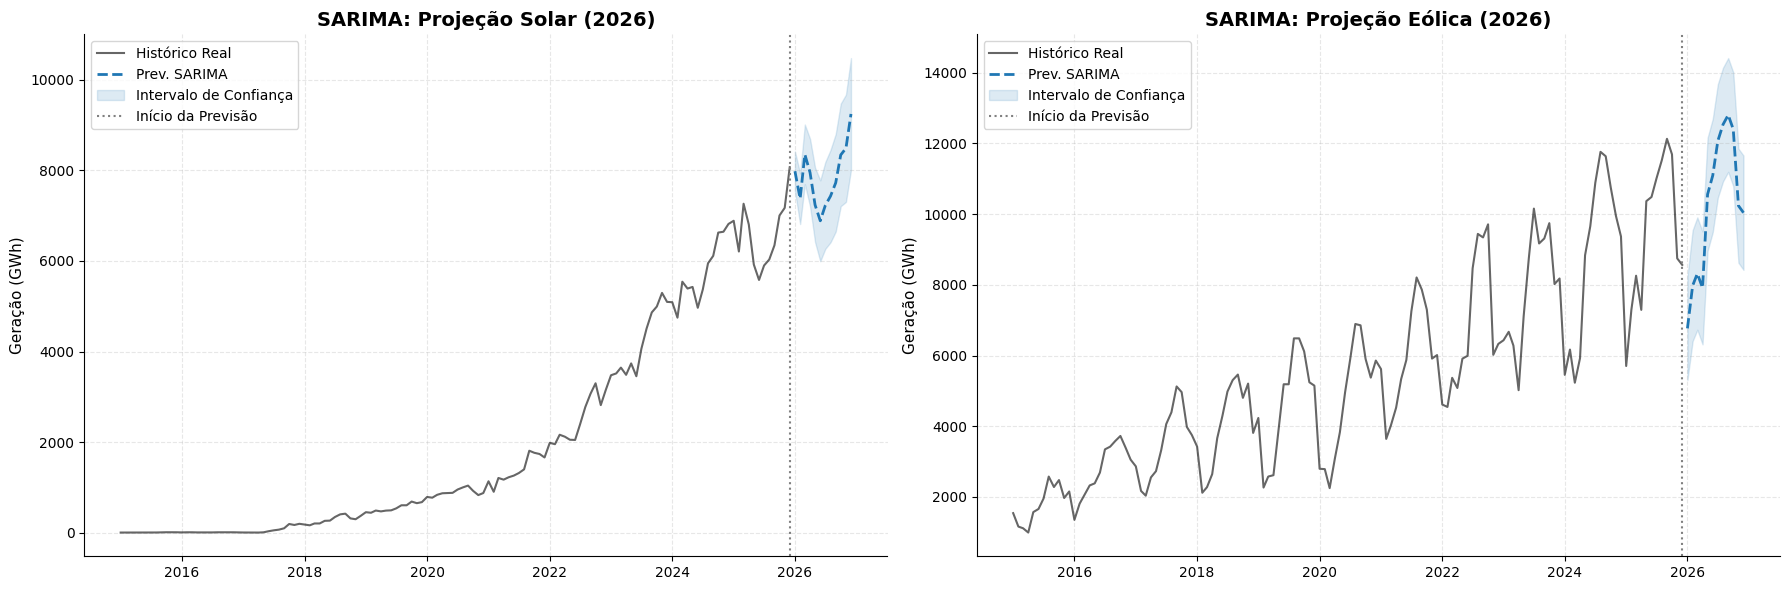

In [122]:
import matplotlib.pyplot as plt

# Criando a figura para comparação SARIMA lado a lado
fig, (ax_s1, ax_s2) = plt.subplots(1, 2, figsize=(18, 6))

# --- Solar - SARIMA ---
# Realizando o forecast novamente para obter o intervalo de confiança
modelo_s = sm.tsa.statespace.SARIMAX(serie_solar, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), enforce_stationarity=False, enforce_invertibility=False)
res_s = modelo_s.fit(disp=False)
pred_s = res_s.get_forecast(steps=PERIODOS_FUTURO)
pred_conf_s = pred_s.conf_int()

ax_s1.plot(serie_solar.index, serie_solar.values, label='Histórico Real', color='black', alpha=0.6)
ax_s1.plot(s_futuro_solar.index, s_futuro_solar.values, label='Prev. SARIMA', color='#1f77b4', linewidth=2, linestyle='--')
ax_s1.fill_between(pred_conf_s.index, pred_conf_s.iloc[:, 0], pred_conf_s.iloc[:, 1], color='#1f77b4', alpha=0.15, label='Intervalo de Confiança')
ax_s1.axvline(x=serie_solar.index[-1], color='gray', linestyle=':', label='Início da Previsão')
ax_s1.set_title("SARIMA: Projeção Solar (2026)", fontsize=14, fontweight='bold')
ax_s1.set_ylabel("Geração (GWh)")
ax_s1.legend()

# --- Eólica - SARIMA ---
modelo_w = sm.tsa.statespace.SARIMAX(serie_wind, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), enforce_stationarity=False, enforce_invertibility=False)
res_w = modelo_w.fit(disp=False)
pred_w = res_w.get_forecast(steps=PERIODOS_FUTURO)
pred_conf_w = pred_w.conf_int()

ax_s2.plot(serie_wind.index, serie_wind.values, label='Histórico Real', color='black', alpha=0.6)
ax_s2.plot(s_futuro_wind.index, s_futuro_wind.values, label='Prev. SARIMA', color='#1f77b4', linewidth=2, linestyle='--')
ax_s2.fill_between(pred_conf_w.index, pred_conf_w.iloc[:, 0], pred_conf_w.iloc[:, 1], color='#1f77b4', alpha=0.15, label='Intervalo de Confiança')
ax_s2.axvline(x=serie_wind.index[-1], color='gray', linestyle=':', label='Início da Previsão')
ax_s2.set_title("SARIMA: Projeção Eólica (2026)", fontsize=14, fontweight='bold')
ax_s2.set_ylabel("Geração (GWh)")
ax_s2.legend()

plt.tight_layout()
plt.show()

## Gráfico de barras - Avaliação das Métricas (MAE, RMSE, MAPE) — Modelo Prophet


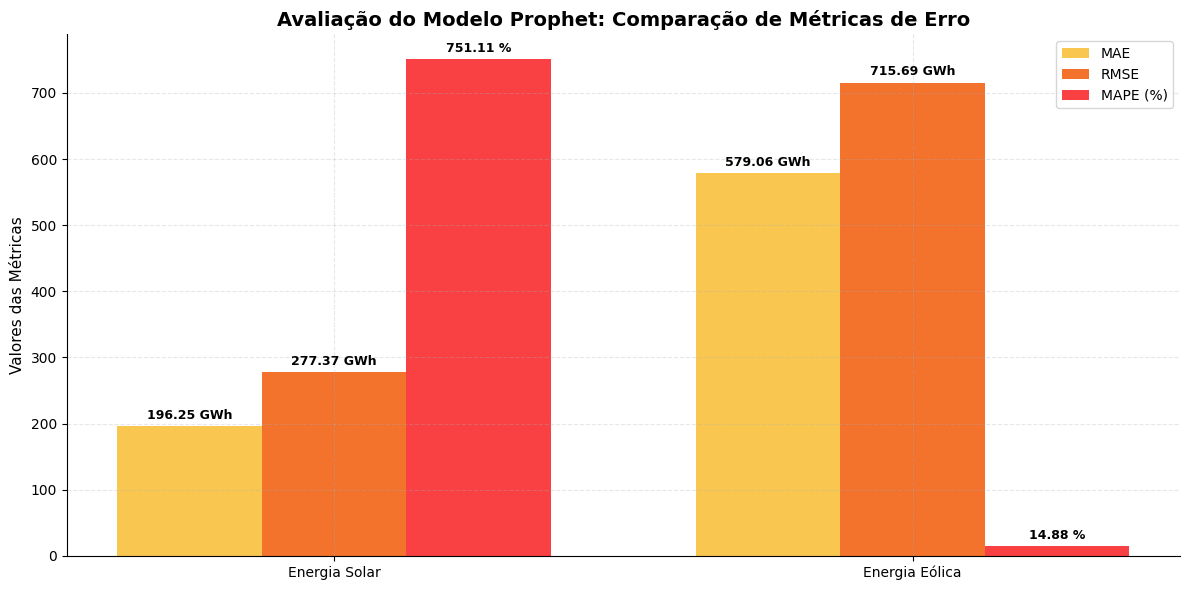

In [123]:
import matplotlib.pyplot as plt
import numpy as np

# Preparação dos dados de métricas para o Prophet
labels = ['Energia Solar', 'Energia Eólica']
mae_vals = [mean_absolute_error(serie_solar, p_hist_solar), mean_absolute_error(serie_wind, p_hist_wind)]
rmse_vals = [np.sqrt(mean_squared_error(serie_solar, p_hist_solar)), np.sqrt(mean_squared_error(serie_wind, p_hist_wind))]
mape_vals = [calcular_mape(serie_solar, p_hist_solar), calcular_mape(serie_wind, p_hist_wind)]

x = np.arange(len(labels))  # Localização das etiquetas
width = 0.25  # Largura das barras

fig, ax = plt.subplots(figsize=(12, 6))

# Criando as barras para cada métrica
rects1 = ax.bar(x - width, mae_vals, width, label='MAE', color='#f9c74f')
rects2 = ax.bar(x, rmse_vals, width, label='RMSE', color='#f3722c')
rects3 = ax.bar(x + width, mape_vals, width, label='MAPE (%)', color='#f94144')

# Textos, títulos e legendas
ax.set_ylabel('Valores das Métricas')
ax.set_title('Avaliação do Modelo Prophet: Comparação de Métricas de Erro', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Função para adicionar rótulos sobre as barras com unidades
def autolabel(rects, unit=""):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f} {unit}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1, "GWh")
autolabel(rects2, "GWh")
autolabel(rects3, "%")

plt.tight_layout()
plt.show()

## Gráfico de barras - Avaliação das Métricas (MAE, RMSE, MAPE) — Modelo SARIMA

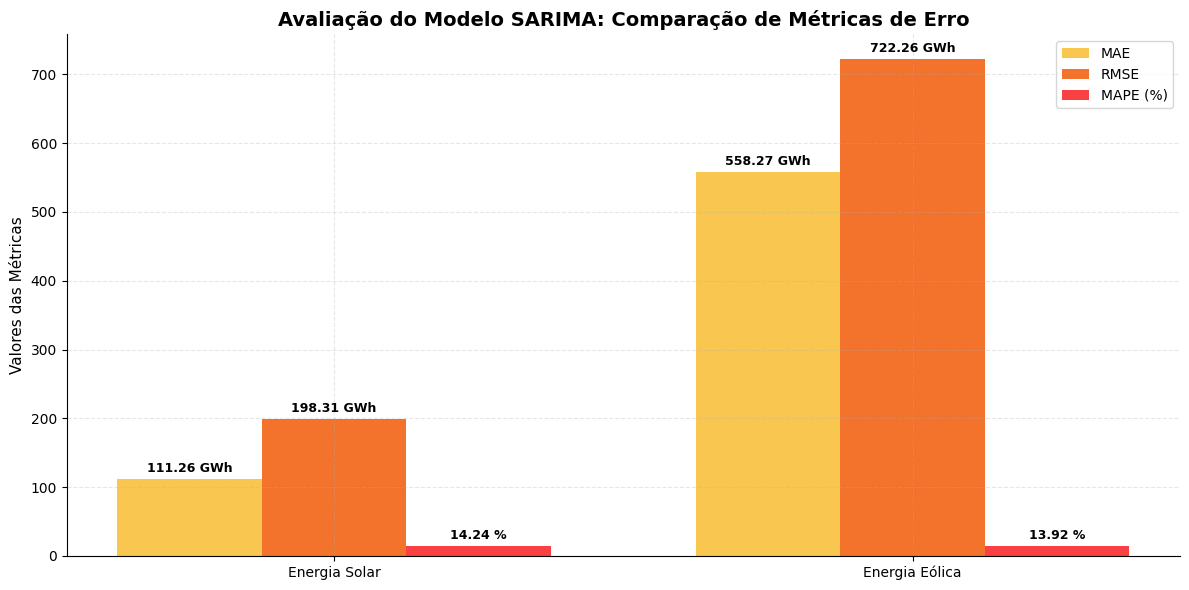

In [124]:
import matplotlib.pyplot as plt
import numpy as np

# Preparação dos dados de métricas para o SARIMA
labels_s = ['Energia Solar', 'Energia Eólica']
mae_s = [mean_absolute_error(serie_solar, s_hist_solar), mean_absolute_error(serie_wind, s_hist_wind)]
rmse_s = [np.sqrt(mean_squared_error(serie_solar, s_hist_solar)), np.sqrt(mean_squared_error(serie_wind, s_hist_wind))]
mape_s = [calcular_mape(serie_solar, s_hist_solar), calcular_mape(serie_wind, s_hist_wind)]

x_s = np.arange(len(labels_s))  # Localização das etiquetas
width_s = 0.25  # Largura das barras

fig, ax = plt.subplots(figsize=(12, 6))

# Criando as barras para cada métrica
rects1s = ax.bar(x_s - width_s, mae_s, width_s, label='MAE', color='#f9c74f')
rects2s = ax.bar(x_s, rmse_s, width_s, label='RMSE', color='#f3722c')
rects3s = ax.bar(x_s + width_s, mape_s, width_s, label='MAPE (%)', color='#f94144')

# Textos, títulos e legendas
ax.set_ylabel('Valores das Métricas')
ax.set_title('Avaliação do Modelo SARIMA: Comparação de Métricas de Erro', fontsize=14, fontweight='bold')
ax.set_xticks(x_s)
ax.set_xticklabels(labels_s)
ax.legend()

# Reutilizando a lógica de rótulos
def autolabel_sarima(rects, unit=""):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f} {unit}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel_sarima(rects1s, "GWh")
autolabel_sarima(rects2s, "GWh")
autolabel_sarima(rects3s, "%")

plt.tight_layout()
plt.show()

## Gráfico de barrras - Comparativo de Desempenho (MAE, RMSE e MAPE): SARIMA vs Prophet


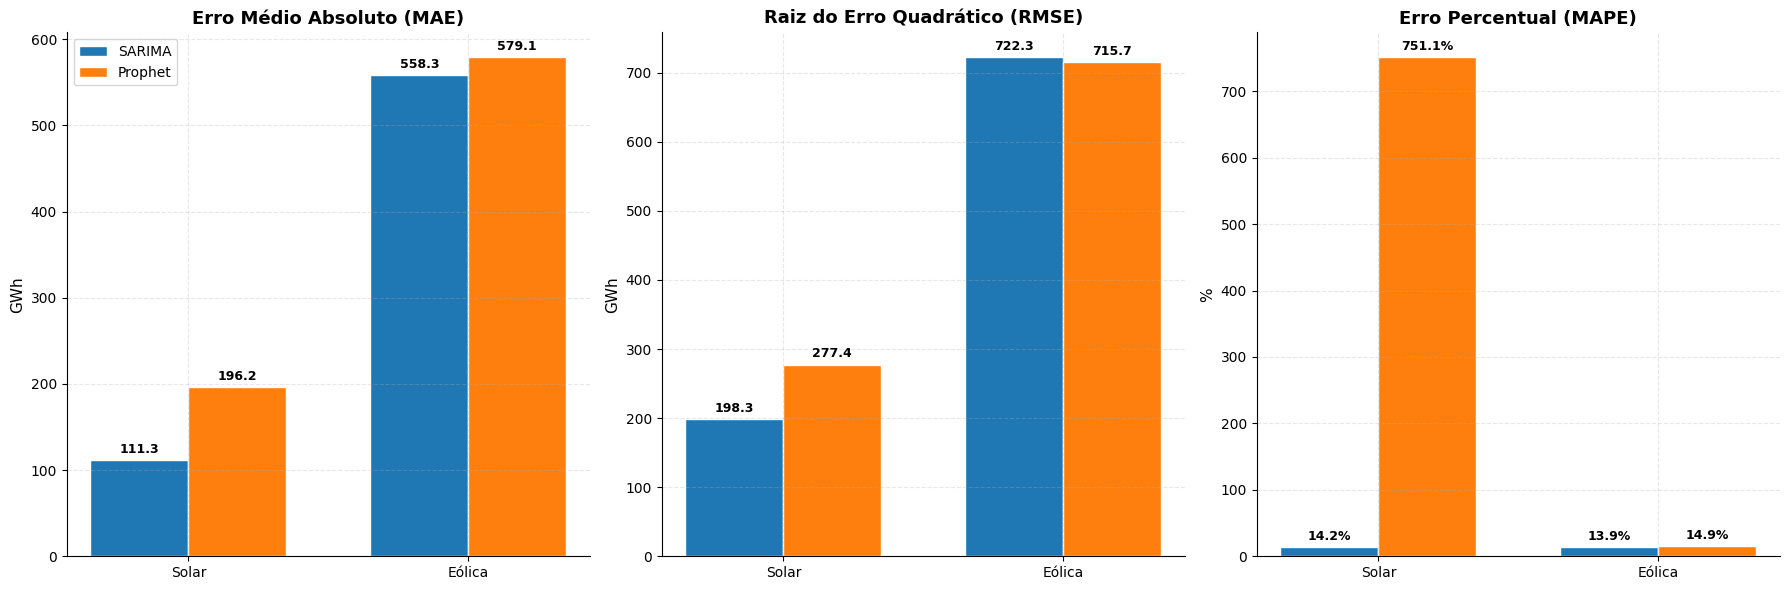

In [125]:
import matplotlib.pyplot as plt
import numpy as np

# Preparação dos dados: Comparativo SARIMA vs Prophet (MAE, RMSE, MAPE)
labels = ['Solar', 'Eólica']

# Métricas SARIMA
mae_sarima = [mean_absolute_error(serie_solar, s_hist_solar), mean_absolute_error(serie_wind, s_hist_wind)]
rmse_sarima = [np.sqrt(mean_squared_error(serie_solar, s_hist_solar)), np.sqrt(mean_squared_error(serie_wind, s_hist_wind))]
mape_sarima = [calcular_mape(serie_solar, s_hist_solar), calcular_mape(serie_wind, s_hist_wind)]

# Métricas Prophet
mae_prophet = [mean_absolute_error(serie_solar, p_hist_solar), mean_absolute_error(serie_wind, p_hist_wind)]
rmse_prophet = [np.sqrt(mean_squared_error(serie_solar, p_hist_solar)), np.sqrt(mean_squared_error(serie_wind, p_hist_wind))]
mape_prophet = [calcular_mape(serie_solar, p_hist_solar), calcular_mape(serie_wind, p_hist_wind)]

# Configuração do Layout de Subplots (um para cada métrica)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
x = np.arange(len(labels))
width = 0.35

# 1. Gráfico MAE
rects1_mae = ax1.bar(x - width/2, mae_sarima, width, label='SARIMA', color='#1f77b4', edgecolor='white')
rects2_mae = ax1.bar(x + width/2, mae_prophet, width, label='Prophet', color='#ff7f0e', edgecolor='white')
ax1.set_title('Erro Médio Absoluto (MAE)', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel('GWh')
ax1.legend()

# 2. Gráfico RMSE
rects1_rmse = ax2.bar(x - width/2, rmse_sarima, width, label='SARIMA', color='#1f77b4', edgecolor='white')
rects2_rmse = ax2.bar(x + width/2, rmse_prophet, width, label='Prophet', color='#ff7f0e', edgecolor='white')
ax2.set_title('Raiz do Erro Quadrático (RMSE)', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel('GWh')

# 3. Gráfico MAPE
rects1_mape = ax3.bar(x - width/2, mape_sarima, width, label='SARIMA', color='#1f77b4', edgecolor='white')
rects2_mape = ax3.bar(x + width/2, mape_prophet, width, label='Prophet', color='#ff7f0e', edgecolor='white')
ax3.set_title('Erro Percentual (MAPE)', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(labels)
ax3.set_ylabel('%')

# Função de rótulos adaptada para os 3 subplots
def autolabel(rects, ax, unit=""):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}{unit}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1_mae, ax1)
autolabel(rects2_mae, ax1)
autolabel(rects1_rmse, ax2)
autolabel(rects2_rmse, ax2)
autolabel(rects1_mape, ax3, "%")
autolabel(rects2_mape, ax3, "%")

plt.tight_layout()
plt.show()


## Gráfico das Projeções Individuais de Crescimento Solar e eólica (2026)

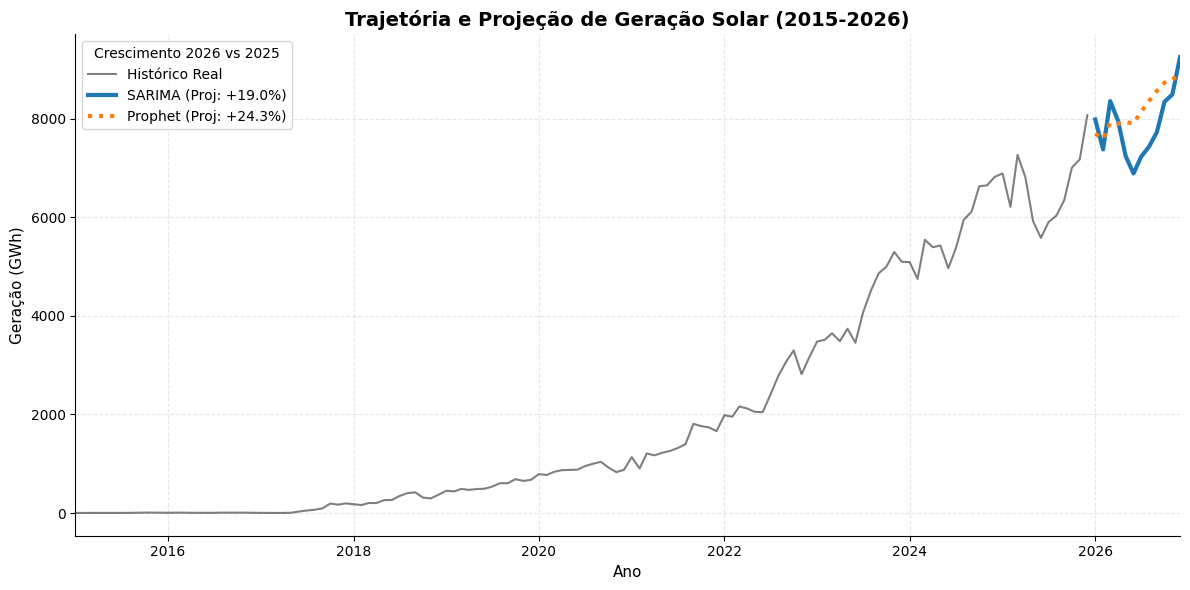

In [126]:
import matplotlib.dates as mdates

def calc_crescimento(serie_historica, serie_previsao):
    """
    Calcula o crescimento percentual da média do último ano histórico
    para a média do ano de previsão.
    """
    ultimo_ano_historico = serie_historica.index.year.max()
    media_historica = serie_historica[serie_historica.index.year == ultimo_ano_historico].mean()

    # Se for um dataframe do Prophet, extrai a coluna ds e yhat
    if isinstance(serie_previsao, pd.DataFrame) and 'ds' in serie_previsao.columns:
        serie_previsao = pd.Series(serie_previsao['yhat'].values, index=pd.to_datetime(serie_previsao['ds']))

    # Se for uma série sem DatetimeIndex
    if not isinstance(serie_previsao.index, pd.DatetimeIndex):
        proximo_ano = ultimo_ano_historico + 1
        idx = pd.date_range(start=f'{proximo_ano}-01-01', periods=len(serie_previsao), freq='MS')
        serie_previsao = pd.Series(serie_previsao.values, index=idx)

    ano_previsao = serie_previsao.index.year.min()
    media_previsao = serie_previsao[serie_previsao.index.year == ano_previsao].mean()

    if media_historica == 0:
        return 0
    return ((media_previsao - media_historica) / media_historica) * 100


# Gráfico Individual: Projeção Solar 2026
fig, ax = plt.subplots(figsize=(12, 6))

c_solar_s = calc_crescimento(serie_solar, s_futuro_solar)
c_solar_p = calc_crescimento(serie_solar, p_futuro_solar)

ax.plot(serie_solar.index, serie_solar.values, label='Histórico Real', color='black', alpha=0.5, linewidth=1.5)
ax.plot(s_futuro_solar.index, s_futuro_solar.values, label=f'SARIMA (Proj: +{c_solar_s:.1f}%)', color='#1f77b4', linewidth=3)
ax.plot(pd.to_datetime(p_futuro_solar['ds']), p_futuro_solar['yhat'], label=f'Prophet (Proj: +{c_solar_p:.1f}%)', color='#ff7f0e', linewidth=3, linestyle=':')

ax.set_title("Trajetória e Projeção de Geração Solar (2015-2026)", fontsize=14, fontweight='bold')
ax.set_ylabel("Geração (GWh)")
ax.set_xlabel("Ano")
ax.legend(title="Crescimento 2026 vs 2025", loc='upper left')
ax.set_xlim([pd.Timestamp('2015-01-01'), pd.Timestamp('2026-12-01')])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

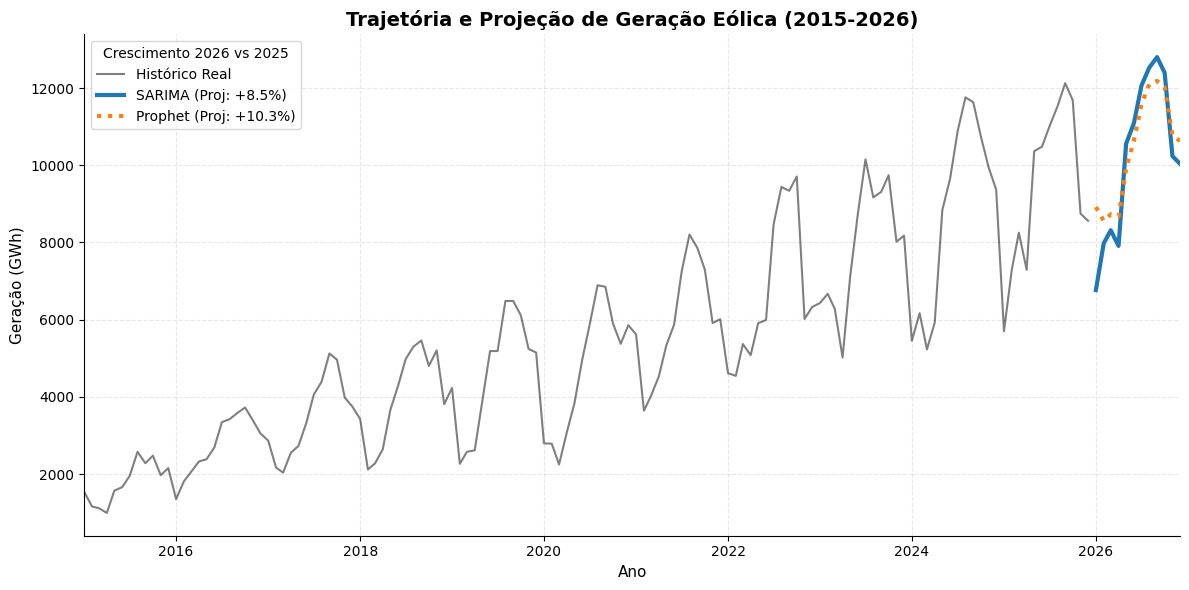

In [127]:
import matplotlib.dates as mdates

# Gráfico Individual: Projeção Eólica 2026
fig, ax = plt.subplots(figsize=(12, 6))

c_wind_s = calc_crescimento(serie_wind, s_futuro_wind)
c_wind_p = calc_crescimento(serie_wind, p_futuro_wind['yhat'])

ax.plot(serie_wind.index, serie_wind.values, label='Histórico Real', color='black', alpha=0.5, linewidth=1.5)
ax.plot(s_futuro_wind.index, s_futuro_wind.values, label=f'SARIMA (Proj: +{c_wind_s:.1f}%)', color='#1f77b4', linewidth=3)
ax.plot(p_futuro_wind['ds'], p_futuro_wind['yhat'], label=f'Prophet (Proj: +{c_wind_p:.1f}%)', color='#ff7f0e', linewidth=3, linestyle=':')

ax.set_title("Trajetória e Projeção de Geração Eólica (2015-2026)", fontsize=14, fontweight='bold')
ax.set_ylabel("Geração (GWh)")
ax.set_xlabel("Ano")
ax.legend(title="Crescimento 2026 vs 2025", loc='upper left')
ax.set_xlim([pd.Timestamp('2015-01-01'), pd.Timestamp('2026-12-01')])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

## Gráficos lado a lado: SARIMA e Prophet para Solar e Eólica

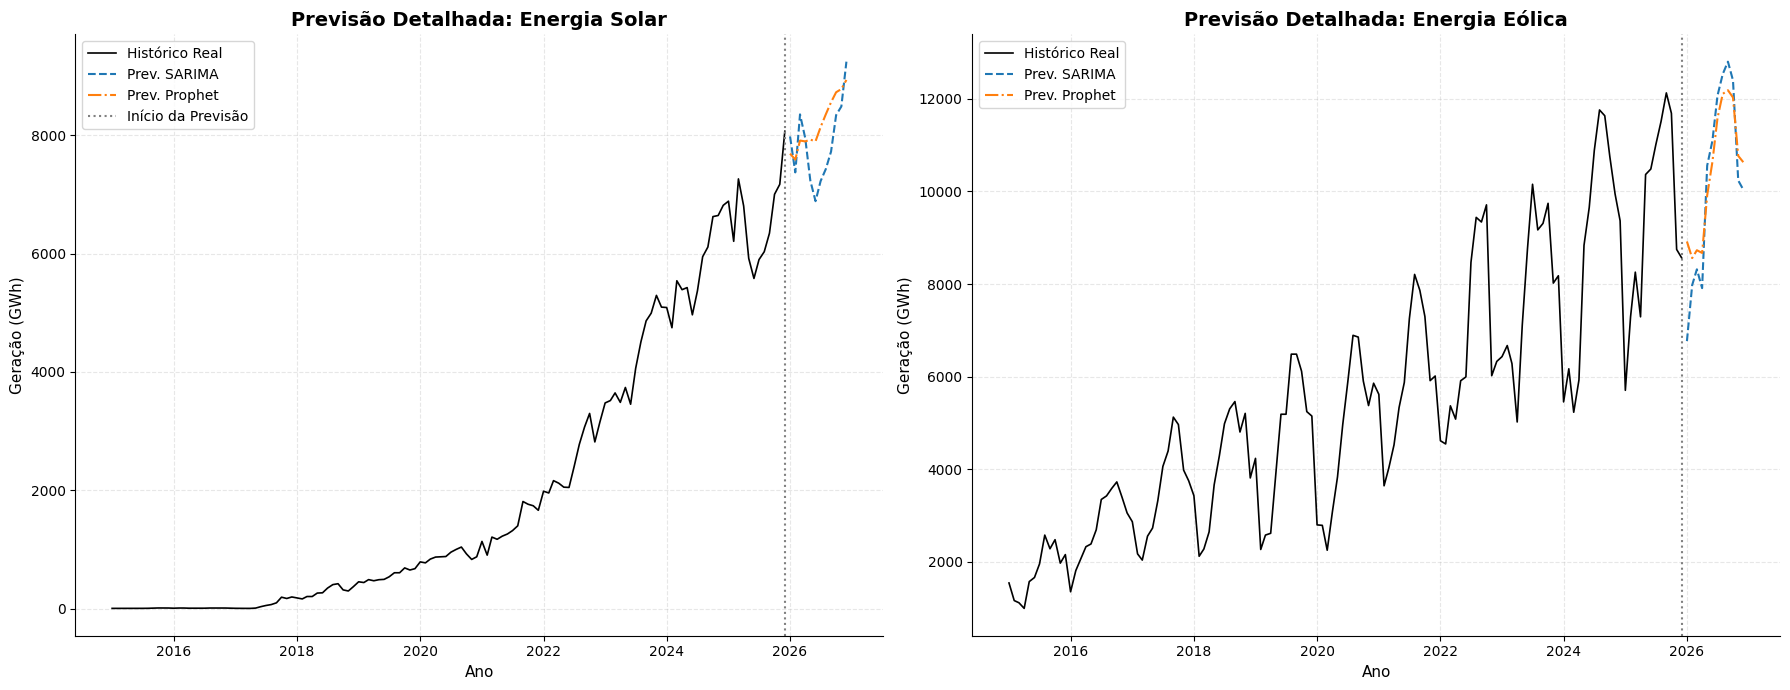

In [128]:
import matplotlib.pyplot as plt

# Cria a figura com 1 linha e 2 colunas para comparação lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Gráfico 1: Energia Solar ---
ax1.plot(serie_solar.index, serie_solar.values, label='Histórico Real', color='black', linewidth=1.2)
ax1.plot(s_futuro_solar.index, s_futuro_solar.values, label='Prev. SARIMA', color='#1f77b4', linestyle='--')
ax1.plot(p_futuro_solar['ds'], p_futuro_solar['yhat'], label='Prev. Prophet', color='#ff7f0e', linestyle='-.')
ax1.axvline(x=serie_solar.index[-1], color='gray', linestyle=':', linewidth=1.5, label='Início da Previsão')
ax1.set_title('Previsão Detalhada: Energia Solar', fontsize=14, fontweight='bold')
ax1.set_ylabel('Geração (GWh)')
ax1.set_xlabel('Ano')
ax1.legend(loc='upper left', fontsize=10)

# --- Gráfico 2: Energia Eólica ---
ax2.plot(serie_wind.index, serie_wind.values, label='Histórico Real', color='black', linewidth=1.2)
ax2.plot(s_futuro_wind.index, s_futuro_wind.values, label='Prev. SARIMA', color='#1f77b4', linestyle='--')
ax2.plot(p_futuro_wind['ds'], p_futuro_wind['yhat'], label='Prev. Prophet', color='#ff7f0e', linestyle='-.')
ax2.axvline(x=serie_wind.index[-1], color='gray', linestyle=':', linewidth=1.5)
ax2.set_title('Previsão Detalhada: Energia Eólica', fontsize=14, fontweight='bold')
ax2.set_ylabel('Geração (GWh)')
ax2.set_xlabel('Ano')
ax2.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

## Gráficos modelo Prophet: Solar e Eólica

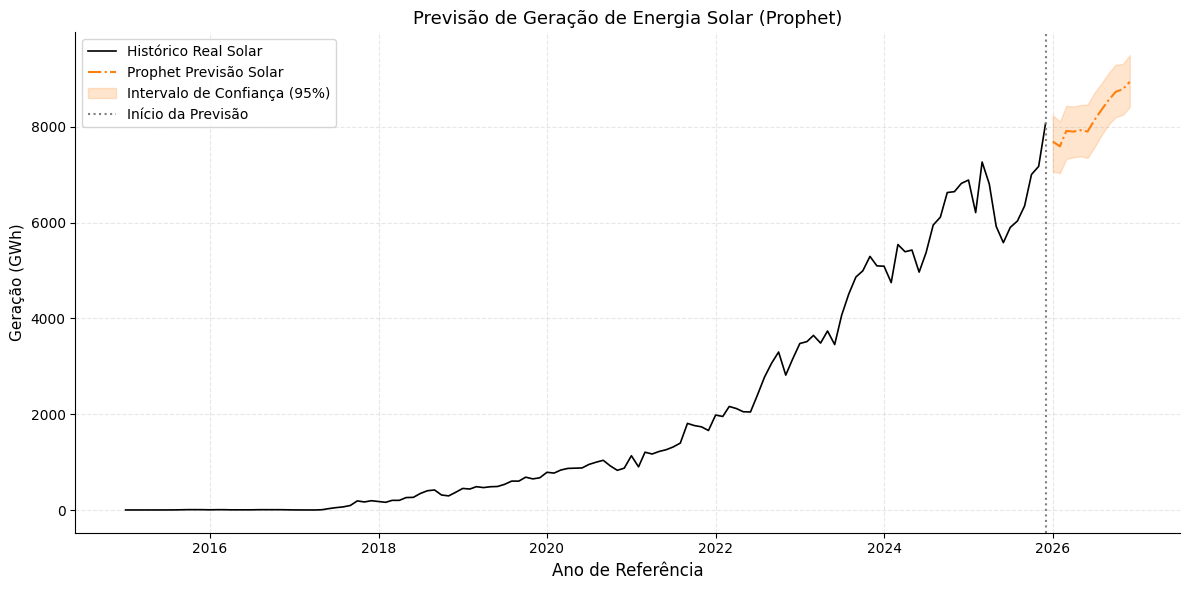

In [133]:
# Grafico Solar
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(serie_solar.index, serie_solar.values, label='Histórico Real Solar', color='black', linewidth=1.2)
ax.plot(p_futuro_solar['ds'], p_futuro_solar['yhat'], label='Prophet Previsão Solar', color='#ff7f0e', linestyle='-.')
ax.fill_between(p_futuro_solar['ds'], p_futuro_solar['yhat_lower'], p_futuro_solar['yhat_upper'], color='#ff7f0e', alpha=0.2, label='Intervalo de Confiança (95%)')
ax.axvline(x=serie_solar.index[-1], color='gray', linestyle=':', linewidth=1.5, label='Início da Previsão')
ax.set_title('Previsão de Geração de Energia Solar (Prophet)', fontsize=13)
ax.set_ylabel('Geração (GWh)')
ax.set_xlabel('Ano de Referência', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

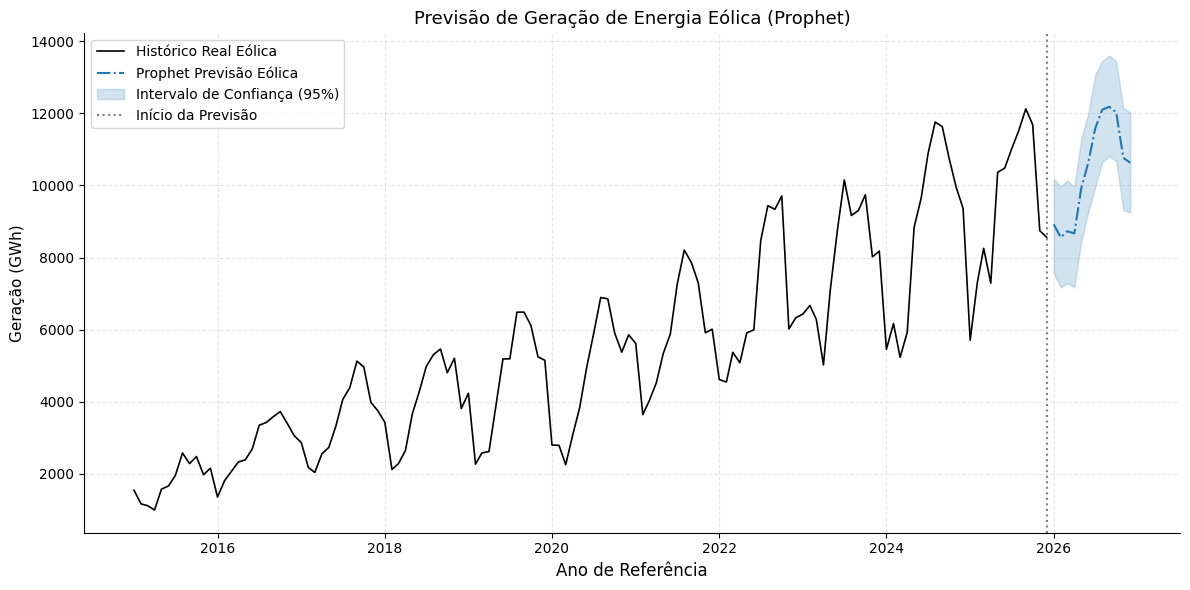

In [137]:
# Grafico Eólica
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(serie_wind.index, serie_wind.values, label='Histórico Real Eólica', color='black', linewidth=1.2)
ax.plot(p_futuro_wind['ds'], p_futuro_wind['yhat'], label='Prophet Previsão Eólica', color='#1f77b4', linestyle='-.')
ax.fill_between(p_futuro_wind['ds'], p_futuro_wind['yhat_lower'], p_futuro_wind['yhat_upper'], color='#1f77b4', alpha=0.2, label='Intervalo de Confiança (95%)')
ax.axvline(x=serie_wind.index[-1], color='gray', linestyle=':', linewidth=1.5, label='Início da Previsão')
ax.set_title('Previsão de Geração de Energia Eólica (Prophet)', fontsize=13)
ax.set_ylabel('Geração (GWh)')
ax.set_xlabel('Ano de Referência', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()